In [104]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd


In [105]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "01_model_data_analysis"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Data Collection

In [106]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "15m", 
    days = 365,
    limit = 1000
)
df = data_collector.collect_data()

In [107]:
df.head()

,timestamp,open,high,low,close,volume
0,2024-09-03 01:15:00,59270.01,59325.55,59203.00,59262.00,102.43589
1,2024-09-03 01:30:00,59262.00,59289.00,59195.50,59212.00,64.80392
2,2024-09-03 01:45:00,59212.00,59403.99,59195.41,59388.01,159.65941
3,2024-09-03 02:00:00,59388.01,59807.42,59347.00,59764.00,818.21451
4,2024-09-03 02:15:00,59763.99,59809.65,59565.00,59581.10,333.29467


In [108]:
df.describe()

,timestamp,open,high,low,close,volume
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078


# Technical Indicators

### Momentum Indicators

#### <font color="#5283fe">Awesome Oscillator (AO)</font>
###### The Awesome Oscillator is an indicator used to measure market momentum. AO calculates the difference of a 34 Period and 5 Period Simple Moving Averages. The Simple Moving Averages that are used are not calculated using closing price but rather each bar’s midpoints. AO is generally used to affirm trends or to anticipate possible reversals.

In [109]:
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

df.describe()

,timestamp,open,high,low,close,volume,AO
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766


#### <font color="#5283fe">Kaufman’s Adaptive Moving Average (KAMA)</font>
###### Moving average designed to account for market noise or volatility. KAMA will closely follow prices when the price swings are relatively small and the noise is low. KAMA will adjust when the price swings widen and follow prices from a greater distance. This trend-following indicator can be used to identify the overall trend, time turning points and filter price movements.

In [110]:
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625


#### <font color="#5283fe">Percentage Price Oscillator (PPO)</font>
###### is a momentum oscillator that measures the difference between two moving averages as a percentage of the larger moving average.

In [111]:
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,35007.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,0.011938
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,-1.531201
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,-0.099391
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,0.011547
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,0.129523
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,1.952636
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,0.256966


#### <font color="#5283fe">Percentage Volume Oscillator (PVO)</font>
###### is a momentum oscillator for volume. The PVO measures the difference between two volume-based moving averages as a percentage of the larger moving average.

In [112]:
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,35007.000000,35015.000000,35007.000000,35007.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,0.011938,-2.946785,-0.001215,-2.946164
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,-1.531201,-48.427842,-21.997736,-45.335848
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,-0.099391,-15.340931,-5.713404,-13.270926
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,0.011547,-4.748205,-1.093677,-3.639386
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,0.129523,7.458919,4.285745,6.624239
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,1.952636,76.785431,61.975881,53.696444
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,0.256966,17.485398,8.490026,14.686574


#### <font color="#5283fe">Rate of Change (ROC)</font>
###### The Rate-of-Change (ROC) indicator, which is also referred to as simply Momentum, is a pure momentum oscillator that measures the percent change in price from one period to the next. The ROC calculation compares the current price with the price “n” periods ago. The plot forms an oscillator that fluctuates above and below the zero line as the Rate-of-Change moves from positive to negative. As a momentum oscillator, ROC signals include centerline crossovers, divergences and overbought-oversold readings.

In [113]:
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,35007.000000,35015.000000,35007.000000,35007.000000,35028.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,0.011938,-2.946785,-0.001215,-2.946164,0.025108
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,-1.531201,-48.427842,-21.997736,-45.335848,-6.448699
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,-0.099391,-15.340931,-5.713404,-13.270926,-0.339494
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,0.011547,-4.748205,-1.093677,-3.639386,0.020562
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,0.129523,7.458919,4.285745,6.624239,0.391361
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,1.952636,76.785431,61.975881,53.696444,10.924205
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,0.256966,17.485398,8.490026,14.686574,0.843481


#### <font color="#5283fe">Relative Strength Index (RSI)</font>
###### Compares the magnitude of recent gains and losses over a specified time period to measure speed and change of price movements of a security. It is primarily used to attempt to identify overbought or oversold conditions in the trading of an asset.

In [114]:
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()
df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,35007.000000,35015.000000,35007.000000,35007.000000,35028.000000,35027.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,0.011938,-2.946785,-0.001215,-2.946164,0.025108,50.599714
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,-1.531201,-48.427842,-21.997736,-45.335848,-6.448699,7.479216
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,-0.099391,-15.340931,-5.713404,-13.270926,-0.339494,43.395262
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,0.011547,-4.748205,-1.093677,-3.639386,0.020562,50.735476
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,0.129523,7.458919,4.285745,6.624239,0.391361,57.928091
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,1.952636,76.785431,61.975881,53.696444,10.924205,89.928399
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,0.256966,17.485398,8.490026,14.686574,0.843481,11.124490


#### <font color="#5283fe">Stochastic RSI</font>
###### The StochRSI oscillator was developed to take advantage of both momentum indicators in order to create a more sensitive indicator that is attuned to a specific security’s historical performance rather than a generalized analysis of price change.

In [115]:
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,35007.000000,35015.000000,35007.000000,35007.000000,35028.000000,35027.000000,35014.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,0.011938,-2.946785,-0.001215,-2.946164,0.025108,50.599714,0.506710
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,-1.531201,-48.427842,-21.997736,-45.335848,-6.448699,7.479216,0.000000
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,-0.099391,-15.340931,-5.713404,-13.270926,-0.339494,43.395262,0.177982
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,0.011547,-4.748205,-1.093677,-3.639386,0.020562,50.735476,0.512567
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,0.129523,7.458919,4.285745,6.624239,0.391361,57.928091,0.838001
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,1.952636,76.785431,61.975881,53.696444,10.924205,89.928399,1.000000
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,0.256966,17.485398,8.490026,14.686574,0.843481,11.124490,0.354274


#### <font color="#5283fe">Stochastic Oscillator</font>
###### Developed in the late 1950s by George Lane. The stochastic oscillator presents the location of the closing price of a stock in relation to the high and low range of the price of a stock over a period of time, typically a 14-day period.

In [116]:
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,35007.000000,35015.000000,35007.000000,35007.000000,35028.000000,35027.000000,35014.000000,35027.000000,35025.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,0.011938,-2.946785,-0.001215,-2.946164,0.025108,50.599714,0.506710,52.121274,52.122365
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,-1.531201,-48.427842,-21.997736,-45.335848,-6.448699,7.479216,0.000000,0.000000,0.130745
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,-0.099391,-15.340931,-5.713404,-13.270926,-0.339494,43.395262,0.177982,26.960476,28.265396
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,0.011547,-4.748205,-1.093677,-3.639386,0.020562,50.735476,0.512567,53.444444,53.294461
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,0.129523,7.458919,4.285745,6.624239,0.391361,57.928091,0.838001,77.559287,76.084756
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,1.952636,76.785431,61.975881,53.696444,10.924205,89.928399,1.000000,100.000000,99.907398
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,0.256966,17.485398,8.490026,14.686574,0.843481,11.124490,0.354274,29.013907,26.776355


#### <font color="#5283fe">True strength index (TSI)</font>
###### Shows both trend direction and overbought/oversold conditions.

In [117]:
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,35007.000000,35015.000000,35007.000000,35007.000000,35028.000000,35027.000000,35014.000000,35027.000000,35025.000000,35003.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,0.011938,-2.946785,-0.001215,-2.946164,0.025108,50.599714,0.506710,52.121274,52.122365,1.196017
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,-1.531201,-48.427842,-21.997736,-45.335848,-6.448699,7.479216,0.000000,0.000000,0.130745,-75.220688
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,-0.099391,-15.340931,-5.713404,-13.270926,-0.339494,43.395262,0.177982,26.960476,28.265396,-11.394582
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,0.011547,-4.748205,-1.093677,-3.639386,0.020562,50.735476,0.512567,53.444444,53.294461,1.336437
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,0.129523,7.458919,4.285745,6.624239,0.391361,57.928091,0.838001,77.559287,76.084756,13.656524
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,1.952636,76.785431,61.975881,53.696444,10.924205,89.928399,1.000000,100.000000,99.907398,70.194852
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,0.256966,17.485398,8.490026,14.686574,0.843481,11.124490,0.354274,29.013907,26.776355,18.954368


### Volume Indicators

#### <font color="#5283fe">Accumulation/Distribution Index (ADI)</font>
###### The accumulation distribution indicator (AD) or accumulation distribution line is a volume-based indicator used to determine the trend of a stock, using the relation between the stock’s price and volume flow.

In [118]:
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35015.000000,35007.000000,35007.000000,35028.000000,35027.000000,35014.000000,35027.000000,35025.000000,35003.000000,35040.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,-2.946785,-0.001215,-2.946164,0.025108,50.599714,0.506710,52.121274,52.122365,1.196017,123625.758124
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-48.427842,-21.997736,-45.335848,-6.448699,7.479216,0.000000,0.000000,0.130745,-75.220688,-10348.408972
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-15.340931,-5.713404,-13.270926,-0.339494,43.395262,0.177982,26.960476,28.265396,-11.394582,124326.646400
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,-4.748205,-1.093677,-3.639386,0.020562,50.735476,0.512567,53.444444,53.294461,1.336437,137252.166723
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,7.458919,4.285745,6.624239,0.391361,57.928091,0.838001,77.559287,76.084756,13.656524,163191.437015
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,76.785431,61.975881,53.696444,10.924205,89.928399,1.000000,100.000000,99.907398,70.194852,195717.360760
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,17.485398,8.490026,14.686574,0.843481,11.124490,0.354274,29.013907,26.776355,18.954368,59252.504321


#### <font color="#5283fe">Chaikin Money Flow (CMF)</font>
###### It measures the amount of Money Flow Volume over a specific period..

In [119]:
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35007.000000,35007.000000,35028.000000,35027.000000,35014.000000,35027.000000,35025.000000,35003.000000,35040.000000,35021.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,-0.001215,-2.946164,0.025108,50.599714,0.506710,52.121274,52.122365,1.196017,123625.758124,0.011495
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-21.997736,-45.335848,-6.448699,7.479216,0.000000,0.000000,0.130745,-75.220688,-10348.408972,-0.615983
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-5.713404,-13.270926,-0.339494,43.395262,0.177982,26.960476,28.265396,-11.394582,124326.646400,-0.094194
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,-1.093677,-3.639386,0.020562,50.735476,0.512567,53.444444,53.294461,1.336437,137252.166723,0.011634
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,4.285745,6.624239,0.391361,57.928091,0.838001,77.559287,76.084756,13.656524,163191.437015,0.115829
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,61.975881,53.696444,10.924205,89.928399,1.000000,100.000000,99.907398,70.194852,195717.360760,0.676539
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,8.490026,14.686574,0.843481,11.124490,0.354274,29.013907,26.776355,18.954368,59252.504321,0.156883


#### <font color="#5283fe">Ease of movement (EoM, EMV)</font>
###### It relate an asset’s price change to its volume and is particularly useful for assessing the strength of a trend.

In [120]:
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()
df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35028.000000,35027.000000,35014.000000,35027.000000,35025.000000,35003.000000,35040.000000,35021.000000,3.503900e+04,3.502600e+04
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.025108,50.599714,0.506710,52.121274,52.122365,1.196017,123625.758124,0.011495,2.273792e+08,2.279444e+08
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-6.448699,7.479216,0.000000,0.000000,0.130745,-75.220688,-10348.408972,-0.615983,-5.815276e+11,-5.372551e+10
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-0.339494,43.395262,0.177982,26.960476,28.265396,-11.394582,124326.646400,-0.094194,-1.043504e+10,-3.076860e+09
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.020562,50.735476,0.512567,53.444444,53.294461,1.336437,137252.166723,0.011634,1.141501e+08,2.377152e+08
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,0.391361,57.928091,0.838001,77.559287,76.084756,13.656524,163191.437015,0.115829,1.056313e+10,3.510773e+09
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,10.924205,89.928399,1.000000,100.000000,99.907398,70.194852,195717.360760,0.676539,2.377418e+11,4.514740e+10
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,0.843481,11.124490,0.354274,29.013907,26.776355,18.954368,59252.504321,0.156883,2.467511e+10,6.727335e+09


#### <font color="#5283fe">Force Index (FI)</font>
###### It illustrates how strong the actual buying or selling pressure is. High positive values mean there is a strong rising trend, and low values signify a strong downward trend.

In [121]:
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35027.000000,35014.000000,35027.000000,35025.000000,35003.000000,35040.000000,35021.000000,3.503900e+04,3.502600e+04,3.502700e+04
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,50.599714,0.506710,52.121274,52.122365,1.196017,123625.758124,0.011495,2.273792e+08,2.279444e+08,8.896787e+02
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,7.479216,0.000000,0.000000,0.130745,-75.220688,-10348.408972,-0.615983,-5.815276e+11,-5.372551e+10,-3.828752e+06
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,43.395262,0.177982,26.960476,28.265396,-11.394582,124326.646400,-0.094194,-1.043504e+10,-3.076860e+09,-6.076642e+03
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,50.735476,0.512567,53.444444,53.294461,1.336437,137252.166723,0.011634,1.141501e+08,2.377152e+08,1.673559e+02
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,57.928091,0.838001,77.559287,76.084756,13.656524,163191.437015,0.115829,1.056313e+10,3.510773e+09,6.800283e+03
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,89.928399,1.000000,100.000000,99.907398,70.194852,195717.360760,0.676539,2.377418e+11,4.514740e+10,4.057538e+06
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,11.124490,0.354274,29.013907,26.776355,18.954368,59252.504321,0.156883,2.467511e+10,6.727335e+09,1.154377e+05


#### <font color="#5283fe">Money Flow Index (MFI)</font>
###### Uses both price and volume to measure buying and selling pressure. It is positive when the typical price rises (buying pressure) and negative when the typical price declines (selling pressure). A ratio of positive and negative money flow is then plugged into an RSI formula to create an oscillator that moves between zero and one hundred.

In [122]:
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35014.000000,35027.000000,35025.000000,35003.000000,35040.000000,35021.000000,3.503900e+04,3.502600e+04,3.502700e+04,35027.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.506710,52.121274,52.122365,1.196017,123625.758124,0.011495,2.273792e+08,2.279444e+08,8.896787e+02,50.090314
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,0.000000,0.000000,0.130745,-75.220688,-10348.408972,-0.615983,-5.815276e+11,-5.372551e+10,-3.828752e+06,0.000000
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,0.177982,26.960476,28.265396,-11.394582,124326.646400,-0.094194,-1.043504e+10,-3.076860e+09,-6.076642e+03,36.877236
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.512567,53.444444,53.294461,1.336437,137252.166723,0.011634,1.141501e+08,2.377152e+08,1.673559e+02,50.118928
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,0.838001,77.559287,76.084756,13.656524,163191.437015,0.115829,1.056313e+10,3.510773e+09,6.800283e+03,63.210876
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,1.000000,100.000000,99.907398,70.194852,195717.360760,0.676539,2.377418e+11,4.514740e+10,4.057538e+06,98.733114
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,0.354274,29.013907,26.776355,18.954368,59252.504321,0.156883,2.467511e+10,6.727335e+09,1.154377e+05,17.868395


#### <font color="#5283fe">Negative Volume Index (NVI)</font>
###### 

In [123]:
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35027.000000,35025.000000,35003.000000,35040.000000,35021.000000,3.503900e+04,3.502600e+04,3.502700e+04,35027.000000,35040.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,52.121274,52.122365,1.196017,123625.758124,0.011495,2.273792e+08,2.279444e+08,8.896787e+02,50.090314,2010.836542
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,0.000000,0.130745,-75.220688,-10348.408972,-0.615983,-5.815276e+11,-5.372551e+10,-3.828752e+06,0.000000,981.741568
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,26.960476,28.265396,-11.394582,124326.646400,-0.094194,-1.043504e+10,-3.076860e+09,-6.076642e+03,36.877236,1284.516294
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,53.444444,53.294461,1.336437,137252.166723,0.011634,1.141501e+08,2.377152e+08,1.673559e+02,50.118928,1868.321774
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,77.559287,76.084756,13.656524,163191.437015,0.115829,1.056313e+10,3.510773e+09,6.800283e+03,63.210876,2834.555609
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,100.000000,99.907398,70.194852,195717.360760,0.676539,2.377418e+11,4.514740e+10,4.057538e+06,98.733114,3237.144219
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,29.013907,26.776355,18.954368,59252.504321,0.156883,2.467511e+10,6.727335e+09,1.154377e+05,17.868395,716.090790


#### <font color="#5283fe">On-balance volume (OBV)</font>
###### It relates price and volume in the stock market. OBV is based on a cumulative total volume.

In [124]:
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35025.000000,35003.000000,35040.000000,35021.000000,3.503900e+04,3.502600e+04,3.502700e+04,35027.000000,35040.000000,35040.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,52.122365,1.196017,123625.758124,0.011495,2.273792e+08,2.279444e+08,8.896787e+02,50.090314,2010.836542,46068.425601
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,0.130745,-75.220688,-10348.408972,-0.615983,-5.815276e+11,-5.372551e+10,-3.828752e+06,0.000000,981.741568,-30588.727060
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,28.265396,-11.394582,124326.646400,-0.094194,-1.043504e+10,-3.076860e+09,-6.076642e+03,36.877236,1284.516294,26238.881162
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,53.294461,1.336437,137252.166723,0.011634,1.141501e+08,2.377152e+08,1.673559e+02,50.118928,1868.321774,42753.593738
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,76.084756,13.656524,163191.437015,0.115829,1.056313e+10,3.510773e+09,6.800283e+03,63.210876,2834.555609,76661.817803
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,99.907398,70.194852,195717.360760,0.676539,2.377418e+11,4.514740e+10,4.057538e+06,98.733114,3237.144219,123672.402033
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,26.776355,18.954368,59252.504321,0.156883,2.467511e+10,6.727335e+09,1.154377e+05,17.868395,716.090790,34093.462413


#### <font color="#5283fe">Volume-price trend (VPT)</font>
###### Is based on a running cumulative volume that adds or substracts a multiple of the percentage change in share price trend and current volume, depending upon the investment’s upward or downward movements.

In [125]:
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35003.000000,35040.000000,35021.000000,3.503900e+04,3.502600e+04,3.502700e+04,35027.000000,35040.000000,35040.000000,35039.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,1.196017,123625.758124,0.011495,2.273792e+08,2.279444e+08,8.896787e+02,50.090314,2010.836542,46068.425601,334.112391
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-75.220688,-10348.408972,-0.615983,-5.815276e+11,-5.372551e+10,-3.828752e+06,0.000000,981.741568,-30588.727060,-205.514683
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-11.394582,124326.646400,-0.094194,-1.043504e+10,-3.076860e+09,-6.076642e+03,36.877236,1284.516294,26238.881162,141.330266
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,1.336437,137252.166723,0.011634,1.141501e+08,2.377152e+08,1.673559e+02,50.118928,1868.321774,42753.593738,403.063215
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,13.656524,163191.437015,0.115829,1.056313e+10,3.510773e+09,6.800283e+03,63.210876,2834.555609,76661.817803,513.564265
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,70.194852,195717.360760,0.676539,2.377418e+11,4.514740e+10,4.057538e+06,98.733114,3237.144219,123672.402033,885.635952
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,18.954368,59252.504321,0.156883,2.467511e+10,6.727335e+09,1.154377e+05,17.868395,716.090790,34093.462413,243.334675


#### <font color="#5283fe">Volume Weighted Average Price (VWAP)</font>
###### VWAP equals the dollar value of all trading periods divided by the total trading volume for the current day. The calculation starts when trading opens and ends when it closes. Because it is good for the current trading day only, intraday periods and data are used in the calculation.

In [126]:
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35040.000000,35021.000000,3.503900e+04,3.502600e+04,3.502700e+04,35027.000000,35040.000000,35040.000000,35039.000000,35027.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,123625.758124,0.011495,2.273792e+08,2.279444e+08,8.896787e+02,50.090314,2010.836542,46068.425601,334.112391,93384.544797
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-10348.408972,-0.615983,-5.815276e+11,-5.372551e+10,-3.828752e+06,0.000000,981.741568,-30588.727060,-205.514683,53284.481149
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,124326.646400,-0.094194,-1.043504e+10,-3.076860e+09,-6.076642e+03,36.877236,1284.516294,26238.881162,141.330266,83810.116649
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,137252.166723,0.011634,1.141501e+08,2.377152e+08,1.673559e+02,50.118928,1868.321774,42753.593738,403.063215,96540.814467
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,163191.437015,0.115829,1.056313e+10,3.510773e+09,6.800283e+03,63.210876,2834.555609,76661.817803,513.564265,105539.803801
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,195717.360760,0.676539,2.377418e+11,4.514740e+10,4.057538e+06,98.733114,3237.144219,123672.402033,885.635952,123726.791087
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,59252.504321,0.156883,2.467511e+10,6.727335e+09,1.154377e+05,17.868395,716.090790,34093.462413,243.334675,17160.507225


### Volatility Indicators

#### <font color="#5283fe">Average True Range (ATR)</font>
###### The indicator provide an indication of the degree of price volatility. Strong moves, in either direction, are often accompanied by large ranges, or large True Ranges.

In [127]:
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP,ATR
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35021.000000,3.503900e+04,3.502600e+04,3.502700e+04,35027.000000,35040.000000,35040.000000,35039.000000,35027.000000,35040.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.011495,2.273792e+08,2.279444e+08,8.896787e+02,50.090314,2010.836542,46068.425601,334.112391,93384.544797,288.622014
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-0.615983,-5.815276e+11,-5.372551e+10,-3.828752e+06,0.000000,981.741568,-30588.727060,-205.514683,53284.481149,0.000000
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-0.094194,-1.043504e+10,-3.076860e+09,-6.076642e+03,36.877236,1284.516294,26238.881162,141.330266,83810.116649,182.335869
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.011634,1.141501e+08,2.377152e+08,1.673559e+02,50.118928,1868.321774,42753.593738,403.063215,96540.814467,255.212509
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,0.115829,1.056313e+10,3.510773e+09,6.800283e+03,63.210876,2834.555609,76661.817803,513.564265,105539.803801,353.220623
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,0.676539,2.377418e+11,4.514740e+10,4.057538e+06,98.733114,3237.144219,123672.402033,885.635952,123726.791087,1749.980973
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,0.156883,2.467511e+10,6.727335e+09,1.154377e+05,17.868395,716.090790,34093.462413,243.334675,17160.507225,154.968137


#### <font color="#5283fe">Bollinger Bands</font>
###### envelopes plotted at a standard deviation level above and below a simple moving average of the price.

In [128]:
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VPT,VWAP,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35039.000000,35027.000000,35040.000000,35021.000000,35040.000000,35021.000000,35040.000000,35021.000000,35021.000000,35021.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,334.112391,93384.544797,288.622014,94026.888468,0.058390,92763.413319,0.059389,93395.150894,0.510799,1.375776
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-205.514683,53284.481149,0.000000,53995.363026,0.000000,52918.978123,0.000000,53569.950000,-0.528913,0.142631
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,141.330266,83810.116649,182.335869,84368.681405,0.000000,83148.147434,0.000000,83799.668000,0.250032,0.682540
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,403.063215,96540.814467,255.212509,97143.173600,0.000000,95976.793734,0.000000,96569.130500,0.524405,1.045895
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,513.564265,105539.803801,353.220623,106174.367054,0.000000,104987.128756,0.000000,105509.741500,0.771224,1.657392
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,885.635952,123726.791087,1749.980973,124306.002125,1.000000,123056.241095,1.000000,123555.717000,1.501067,15.228677
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,243.334675,17160.507225,154.968137,17215.053541,0.234484,17114.508050,0.236355,17157.131757,0.330605,1.120955


#### <font color="#5283fe">Donchian Channel</font>
###### Donchian channels are technical indicators primarily used to identify breakout points and retracements, which are key for traders looking to capture significant trends.

In [129]:
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35021.000000,35040.000000,35021.000000,35021.000000,35021.000000,35021.000000,35021.000000,35021.000000,35021.000000,35021.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,92763.413319,0.059389,93395.150894,0.510799,1.375776,94070.221594,92672.017862,93371.119728,0.524161,1.524238
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,52918.978123,0.000000,53569.950000,-0.528913,0.142631,53997.000000,52550.000000,53273.500000,0.000000,0.173211
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,83148.147434,0.000000,83799.668000,0.250032,0.682540,84400.000000,83040.290000,83769.120000,0.276405,0.833250
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,95976.793734,0.000000,96569.130500,0.524405,1.045895,97200.700000,95800.000000,96527.585000,0.537627,1.220322
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,104987.128756,0.000000,105509.741500,0.771224,1.657392,106252.000000,104872.500000,105517.600000,0.776128,1.854977
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,123056.241095,1.000000,123555.717000,1.501067,15.228677,124474.000000,123116.100000,123795.050000,1.000000,11.277466
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,17114.508050,0.236355,17157.131757,0.330605,1.120955,17210.674578,17108.337190,17152.536144,0.286942,1.075063


#### <font color="#5283fe">Keltner Channels</font>
###### Keltner Channels are a trend following indicator used to identify reversals with channel breakouts and channel direction. Channels can also be used to identify overbought and oversold levels when the trend is flat.

In [130]:
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35021.000000,35021.000000,35021.000000,35040.000000,35040.000000,35040.000000,35040.000000,35021.000000,35040.000000,35021.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,93371.119728,0.524161,1.524238,93663.765821,0.269235,93086.355246,0.242180,93393.532304,0.535183,0.629774
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,53273.500000,0.000000,0.173211,53898.578500,0.000000,53189.318167,0.000000,53555.244167,-3.216477,0.055367
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,83769.120000,0.276405,0.833250,84105.296792,0.000000,83456.214292,0.000000,83801.397000,0.019021,0.385075
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,96527.585000,0.537627,1.220322,96820.902667,0.000000,96299.276833,0.000000,96568.459333,0.543788,0.544789
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,105517.600000,0.776128,1.854977,105742.411458,1.000000,105289.666167,0.000000,105510.509333,1.044283,0.768217
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,123795.050000,1.000000,11.277466,123911.171000,1.000000,123230.738667,1.000000,123561.387167,4.812792,3.136463
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,17152.536144,0.286942,1.075063,17191.849825,0.443569,17150.471212,0.428409,17156.696298,0.815365,0.364955


#### <font color="#5283fe">Ulcer Index</font>
######  is a technical indicator used in finance to measure downside risk and volatility, specifically the amount of price drawdown or retracement over a period.

In [131]:
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35021.000000,35021.000000,35040.000000,35040.000000,35040.000000,35040.000000,35021.000000,35040.000000,35021.000000,35027.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.524161,1.524238,93663.765821,0.269235,93086.355246,0.242180,93393.532304,0.535183,0.629774,0.535417
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,0.000000,0.173211,53898.578500,0.000000,53189.318167,0.000000,53555.244167,-3.216477,0.055367,0.007338
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,0.276405,0.833250,84105.296792,0.000000,83456.214292,0.000000,83801.397000,0.019021,0.385075,0.226545
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.537627,1.220322,96820.902667,0.000000,96299.276833,0.000000,96568.459333,0.543788,0.544789,0.387862
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,0.776128,1.854977,105742.411458,1.000000,105289.666167,0.000000,105510.509333,1.044283,0.768217,0.658293
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,1.000000,11.277466,123911.171000,1.000000,123230.738667,1.000000,123561.387167,4.812792,3.136463,4.647333
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,0.286942,1.075063,17191.849825,0.443569,17150.471212,0.428409,17156.696298,0.815365,0.364955,0.494636


### Trend Indicators

#### <font color="#5283fe">Average Directional Movement Index (ADX)</font>
######  The Plus Directional Indicator (+DI) and Minus Directional Indicator (-DI) are derived from smoothed averages of these differences, and measure trend direction over time. These two indicators are often referred to collectively as the Directional Movement Indicator (DMI).

In [132]:
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35040.000000,35040.000000,35040.000000,35021.000000,35040.000000,35021.000000,35027.000000,35040.000000,35040.000000,35040.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.269235,93086.355246,0.242180,93393.532304,0.535183,0.629774,0.535417,25.131197,21.555168,21.583803
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,0.000000,53189.318167,0.000000,53555.244167,-3.216477,0.055367,0.007338,0.000000,0.000000,0.000000
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,0.000000,83456.214292,0.000000,83801.397000,0.019021,0.385075,0.226545,17.243519,16.207011,16.439528
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.000000,96299.276833,0.000000,96568.459333,0.543788,0.544789,0.387862,23.207879,20.897058,20.999168
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,1.000000,105289.666167,0.000000,105510.509333,1.044283,0.768217,0.658293,31.071556,26.193122,26.136110
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,1.000000,123230.738667,1.000000,123561.387167,4.812792,3.136463,4.647333,68.448844,72.465025,65.360835
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,0.443569,17150.471212,0.428409,17156.696298,0.815365,0.364955,0.494636,10.506718,7.646380,7.333498


#### <font color="#5283fe">Aroon Indicator</font>
###### Identify when trends are likely to change direction.

In [133]:
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35021.000000,35040.000000,35021.000000,35027.000000,35040.000000,35040.000000,35040.000000,35015.000000,35015.000000,35015.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,93393.532304,0.535183,0.629774,0.535417,25.131197,21.555168,21.583803,47.985035,46.236070,1.748965
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,53555.244167,-3.216477,0.055367,0.007338,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,83801.397000,0.019021,0.385075,0.226545,17.243519,16.207011,16.439528,12.000000,12.000000,-52.000000
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,96568.459333,0.543788,0.544789,0.387862,23.207879,20.897058,20.999168,48.000000,44.000000,8.000000
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,105510.509333,1.044283,0.768217,0.658293,31.071556,26.193122,26.136110,84.000000,80.000000,56.000000
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,123561.387167,4.812792,3.136463,4.647333,68.448844,72.465025,65.360835,100.000000,100.000000,100.000000
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,17156.696298,0.815365,0.364955,0.494636,10.506718,7.646380,7.333498,35.421644,35.411434,60.498286


#### <font color="#5283fe">Commodity Channel Index (CCI)</font>
###### CCI measures the difference between a security’s price change and its average price change. High positive readings indicate that prices are well above their average, which is a show of strength. Low negative readings indicate that prices are well below their average, which is a show of weakness.

In [134]:
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35040.000000,35021.000000,35027.000000,35040.000000,35040.000000,35040.000000,35015.000000,35015.000000,35015.000000,35021.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.535183,0.629774,0.535417,25.131197,21.555168,21.583803,47.985035,46.236070,1.748965,3.683259
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-3.216477,0.055367,0.007338,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-542.978684
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,0.019021,0.385075,0.226545,17.243519,16.207011,16.439528,12.000000,12.000000,-52.000000,-81.365246
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.543788,0.544789,0.387862,23.207879,20.897058,20.999168,48.000000,44.000000,8.000000,8.073064
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,1.044283,0.768217,0.658293,31.071556,26.193122,26.136110,84.000000,80.000000,56.000000,88.113998
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,4.812792,3.136463,4.647333,68.448844,72.465025,65.360835,100.000000,100.000000,100.000000,478.440193
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,0.815365,0.364955,0.494636,10.506718,7.646380,7.333498,35.421644,35.411434,60.498286,112.174342


#### <font color="#5283fe">Detrended Price Oscillator (DPO)</font>
###### Is an indicator designed to remove trend from price and make it easier to identify cycles.

In [135]:
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35021.000000,35027.000000,35040.000000,35040.000000,35040.000000,35015.000000,35015.000000,35015.000000,35021.000000,35021.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.629774,0.535417,25.131197,21.555168,21.583803,47.985035,46.236070,1.748965,3.683259,-2.248242
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,0.055367,0.007338,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-542.978684,-3439.470000
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,0.385075,0.226545,17.243519,16.207011,16.439528,12.000000,12.000000,-52.000000,-81.365246,-137.650500
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.544789,0.387862,23.207879,20.897058,20.999168,48.000000,44.000000,8.000000,8.073064,0.169500
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,0.768217,0.658293,31.071556,26.193122,26.136110,84.000000,80.000000,56.000000,88.113998,135.352500
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,3.136463,4.647333,68.448844,72.465025,65.360835,100.000000,100.000000,100.000000,478.440193,2698.653500
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,0.364955,0.494636,10.506718,7.646380,7.333498,35.421644,35.411434,60.498286,112.174342,299.732330


#### <font color="#5283fe">EMA - Exponential Moving Average</font>
###### .

In [136]:
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35027.000000,35040.000000,35040.000000,35040.000000,35015.000000,35015.000000,35015.000000,35021.000000,35021.000000,35027.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.535417,25.131197,21.555168,21.583803,47.985035,46.236070,1.748965,3.683259,-2.248242,93393.760433
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,0.007338,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-542.978684,-3439.470000,53543.541888
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,0.226545,17.243519,16.207011,16.439528,12.000000,12.000000,-52.000000,-81.365246,-137.650500,83821.248420
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.387862,23.207879,20.897058,20.999168,48.000000,44.000000,8.000000,8.073064,0.169500,96570.880487
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,0.658293,31.071556,26.193122,26.136110,84.000000,80.000000,56.000000,88.113998,135.352500,105514.760650
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,4.647333,68.448844,72.465025,65.360835,100.000000,100.000000,100.000000,478.440193,2698.653500,123515.159154
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,0.494636,10.506718,7.646380,7.333498,35.421644,35.411434,60.498286,112.174342,299.732330,17159.167755


#### <font color="#5283fe">KST Oscillator (KST Signal)</font>
###### It is useful to identify major stock market cycle junctures because its formula is weighed to be more greatly influenced by the longer and more dominant time spans, in order to better reflect the primary swings of stock market cycle.

In [137]:
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35040.000000,35015.000000,35015.000000,35015.000000,35021.000000,35021.000000,35027.000000,35026.000000,35026.000000,35026.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,21.583803,47.985035,46.236070,1.748965,3.683259,-2.248242,93393.760433,0.316882,0.278210,0.038672
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,0.000000,0.000000,0.000000,-100.000000,-542.978684,-3439.470000,53543.541888,-347.686399,-347.686399,-18.985339
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,16.439528,12.000000,12.000000,-52.000000,-81.365246,-137.650500,83821.248420,-3.600092,-3.540703,-1.386913
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,20.999168,48.000000,44.000000,8.000000,8.073064,0.169500,96570.880487,0.367765,0.356252,-0.000255
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,26.136110,84.000000,80.000000,56.000000,88.113998,135.352500,105514.760650,4.605121,4.501988,1.396787
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,65.360835,100.000000,100.000000,100.000000,478.440193,2698.653500,123515.159154,79.976999,76.887477,66.777728
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,7.333498,35.421644,35.411434,60.498286,112.174342,299.732330,17159.167755,10.900101,11.277714,3.205249


#### <font color="#5283fe">Moving Average Convergence Divergence (MACD)</font>
###### Is a trend-following momentum indicator that shows the relationship between two moving averages of prices.

In [138]:
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35015.000000,35021.000000,35021.000000,35027.000000,35026.000000,35026.000000,35026.000000,35015.000000,35007.000000,35007.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,1.748965,3.683259,-2.248242,93393.760433,0.316882,0.278210,0.038672,10.366571,10.360334,0.026346
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-100.000000,-542.978684,-3439.470000,53543.541888,-347.686399,-347.686399,-18.985339,-1543.722834,-1358.673480,-547.233351
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-52.000000,-81.365246,-137.650500,83821.248420,-3.600092,-3.540703,-1.386913,-96.901467,-92.291705,-34.744282
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,8.000000,8.073064,0.169500,96570.880487,0.367765,0.356252,-0.000255,10.360746,10.356821,-0.273737
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,56.000000,88.113998,135.352500,105514.760650,4.605121,4.501988,1.396787,124.382178,119.164043,35.298720
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,100.000000,478.440193,2698.653500,123515.159154,79.976999,76.887477,66.777728,2080.738878,1753.019765,825.912095
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,60.498286,112.174342,299.732330,17159.167755,10.900101,11.277714,3.205249,250.305625,235.676529,75.476011


#### <font color="#5283fe">Mass Index (MI)</font>
###### It uses the high-low range to identify trend reversals based on range expansions. It identifies range bulges that can foreshadow a reversal of the current trend.

In [139]:
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35021.000000,35021.000000,35027.000000,35026.000000,35026.000000,35026.000000,35015.000000,35007.000000,35007.000000,35000.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,3.683259,-2.248242,93393.760433,0.316882,0.278210,0.038672,10.366571,10.360334,0.026346,24.924366
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-542.978684,-3439.470000,53543.541888,-347.686399,-347.686399,-18.985339,-1543.722834,-1358.673480,-547.233351,18.994832
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-81.365246,-137.650500,83821.248420,-3.600092,-3.540703,-1.386913,-96.901467,-92.291705,-34.744282,23.605968
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,8.073064,0.169500,96570.880487,0.367765,0.356252,-0.000255,10.360746,10.356821,-0.273737,24.763418
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,88.113998,135.352500,105514.760650,4.605121,4.501988,1.396787,124.382178,119.164043,35.298720,26.179890
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,478.440193,2698.653500,123515.159154,79.976999,76.887477,66.777728,2080.738878,1753.019765,825.912095,32.398739
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,112.174342,299.732330,17159.167755,10.900101,11.277714,3.205249,250.305625,235.676529,75.476011,1.790095


#### <font color="#5283fe">SMA - Simple Moving Average</font>
###### 

In [140]:
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35021.000000,35027.000000,35026.000000,35026.000000,35026.000000,35015.000000,35007.000000,35007.000000,35000.000000,35027.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,-2.248242,93393.760433,0.316882,0.278210,0.038672,10.366571,10.360334,0.026346,24.924366,93393.752914
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-3439.470000,53543.541888,-347.686399,-347.686399,-18.985339,-1543.722834,-1358.673480,-547.233351,18.994832,53486.857143
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-137.650500,83821.248420,-3.600092,-3.540703,-1.386913,-96.901467,-92.291705,-34.744282,23.605968,83819.516071
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.169500,96570.880487,0.367765,0.356252,-0.000255,10.360746,10.356821,-0.273737,24.763418,96574.905000
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,135.352500,105514.760650,4.605121,4.501988,1.396787,124.382178,119.164043,35.298720,26.179890,105517.034286
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,2698.653500,123515.159154,79.976999,76.887477,66.777728,2080.738878,1753.019765,825.912095,32.398739,123646.237857
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,299.732330,17159.167755,10.900101,11.277714,3.205249,250.305625,235.676529,75.476011,1.790095,17160.811003


#### <font color="#5283fe">Vortex Indicator (VI)</font>
###### It consists of two oscillators that capture positive and negative trend movement. A bullish signal triggers when the positive trend indicator crosses above the negative trend indicator or a key level.

In [141]:
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35026.000000,35026.000000,35015.000000,35007.000000,35007.000000,35000.000000,35027.000000,35026.000000,35026.000000,35026.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.278210,0.038672,10.366571,10.360334,0.026346,24.924366,93393.752914,1.009123,0.992486,0.016637
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-347.686399,-18.985339,-1543.722834,-1358.673480,-547.233351,18.994832,53486.857143,0.428274,0.260890,-1.069625
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-3.540703,-1.386913,-96.901467,-92.291705,-34.744282,23.605968,83819.516071,0.896148,0.884255,-0.207900
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,0.356252,-0.000255,10.360746,10.356821,-0.273737,24.763418,96574.905000,1.010280,0.996821,0.014665
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,4.501988,1.396787,124.382178,119.164043,35.298720,26.179890,105517.034286,1.123916,1.105419,0.238162
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,76.887477,66.777728,2080.738878,1753.019765,825.912095,32.398739,123646.237857,1.671132,1.622736,1.384541
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,11.277714,3.205249,250.305625,235.676529,75.476011,1.790095,17160.811003,0.164361,0.160760,0.320185


#### <font color="#5283fe">WMA - Weighted Moving Average</font>
###### .

In [142]:
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

df.describe()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,35040,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35007.000000,35031.000000,35015.000000,35007.000000,...,35026.000000,35015.000000,35007.000000,35007.000000,35000.000000,35027.000000,35026.000000,35026.000000,35026.000000,35027.000000
mean,2025-03-04 13:07:30,93389.282120,93532.694915,93243.981901,93390.765563,262.105277,21.573153,93386.076496,0.011937,0.000031,...,0.038672,10.366571,10.360334,0.026346,24.924366,93393.752914,1.009123,0.992486,0.016637,93396.966429
min,2024-09-03 01:15:00,52888.000000,53312.060000,52550.000000,52887.990000,3.985380,-3964.689735,53708.106727,-1.742898,-0.520475,...,-18.985339,-1543.722834,-1358.673480,-547.233351,18.994832,53486.857143,0.428274,0.260890,-1.069625,53419.344667
25%,2024-12-03 07:11:15,83791.677500,83938.747500,83654.922500,83792.102500,92.119020,-252.641294,83730.257766,-0.105731,-0.037887,...,-1.386913,-96.901467,-92.291705,-34.744282,23.605968,83819.516071,0.896148,0.884255,-0.207900,83825.150810
50%,2025-03-04 13:07:30,96557.230000,96679.625000,96423.420000,96557.305000,162.064615,23.983471,96555.499542,0.011186,-0.000457,...,-0.000255,10.360746,10.356821,-0.273737,24.763418,96574.905000,1.010280,0.996821,0.014665,96577.009238
75%,2025-06-03 19:03:45,105549.940000,105687.905000,105435.567500,105550.000000,298.946725,305.890676,105503.660036,0.134483,0.038226,...,1.396787,124.382178,119.164043,35.298720,26.179890,105517.034286,1.123916,1.105419,0.238162,105528.042429
max,2025-09-03 01:00:00,124243.310000,124474.000000,123666.010000,124243.320000,8732.379209,5907.463059,123204.907512,2.326518,0.909445,...,66.777728,2080.738878,1753.019765,825.912095,32.398739,123646.237857,1.671132,1.622736,1.384541,123617.738762
std,NaN,17169.723506,17178.676514,17158.449326,17169.022253,337.763078,635.620766,17162.696625,0.272842,0.082092,...,3.205249,250.305625,235.676529,75.476011,1.790095,17160.811003,0.164361,0.160760,0.320185,17159.881371


### Constants

In [143]:
OCHLV = ["open", "close", "high", "low", "volume"]
MOMENTUM = ["AO", "KAMA", "PPO", "PPO_HIST", "PPO_SIGNAL", "PVO", "PVO_HIST", "PVO_SIGNAL", "ROC", "RSI", "STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL", "TSI"]
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

# Data Structure

In [144]:
df.head(10)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
0,2024-09-03 01:15:00,59270.01,59325.55,59203.00,59262.00,102.43589,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-09-03 01:30:00,59262.00,59289.00,59195.50,59212.00,64.80392,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-09-03 01:45:00,59212.00,59403.99,59195.41,59388.01,159.65941,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-09-03 02:00:00,59388.01,59807.42,59347.00,59764.00,818.21451,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-09-03 02:15:00,59763.99,59809.65,59565.00,59581.10,333.29467,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2024-09-03 02:30:00,59581.10,59649.00,59405.15,59450.01,302.55811,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024-09-03 02:45:00,59450.02,59490.00,59300.00,59311.01,169.11409,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2024-09-03 03:00:00,59311.01,59327.71,59238.00,59289.99,171.87523,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2024-09-03 03:15:00,59289.99,59319.97,59126.65,59126.65,103.84995,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2024-09-03 03:30:00,59126.66,59196.00,59126.65,59150.99,81.48941,NaN,59150.99,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            35040 non-null  datetime64[ns]
 1   open                 35040 non-null  float64       
 2   high                 35040 non-null  float64       
 3   low                  35040 non-null  float64       
 4   close                35040 non-null  float64       
 5   volume               35040 non-null  float64       
 6   AO                   35007 non-null  float64       
 7   KAMA                 35031 non-null  float64       
 8   PPO                  35015 non-null  float64       
 9   PPO_HIST             35007 non-null  float64       
 10  PPO_SIGNAL           35007 non-null  float64       
 11  PVO                  35015 non-null  float64       
 12  PVO_HIST             35007 non-null  float64       
 13  PVO_SIGNAL           35007 non-

### Histogram by section

##### <font color="yellow"> OCHLV </font>

In [146]:
df[OCHLV].describe()

,open,close,high,low,volume
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,93389.282120,93390.765563,93532.694915,93243.981901,262.105277
std,17169.723506,17169.022253,17178.676514,17158.449326,337.763078
min,52888.000000,52887.990000,53312.060000,52550.000000,3.985380
25%,83791.677500,83792.102500,83938.747500,83654.922500,92.119020
50%,96557.230000,96557.305000,96679.625000,96423.420000,162.064615
75%,105549.940000,105550.000000,105687.905000,105435.567500,298.946725
max,124243.310000,124243.320000,124474.000000,123666.010000,8732.379209


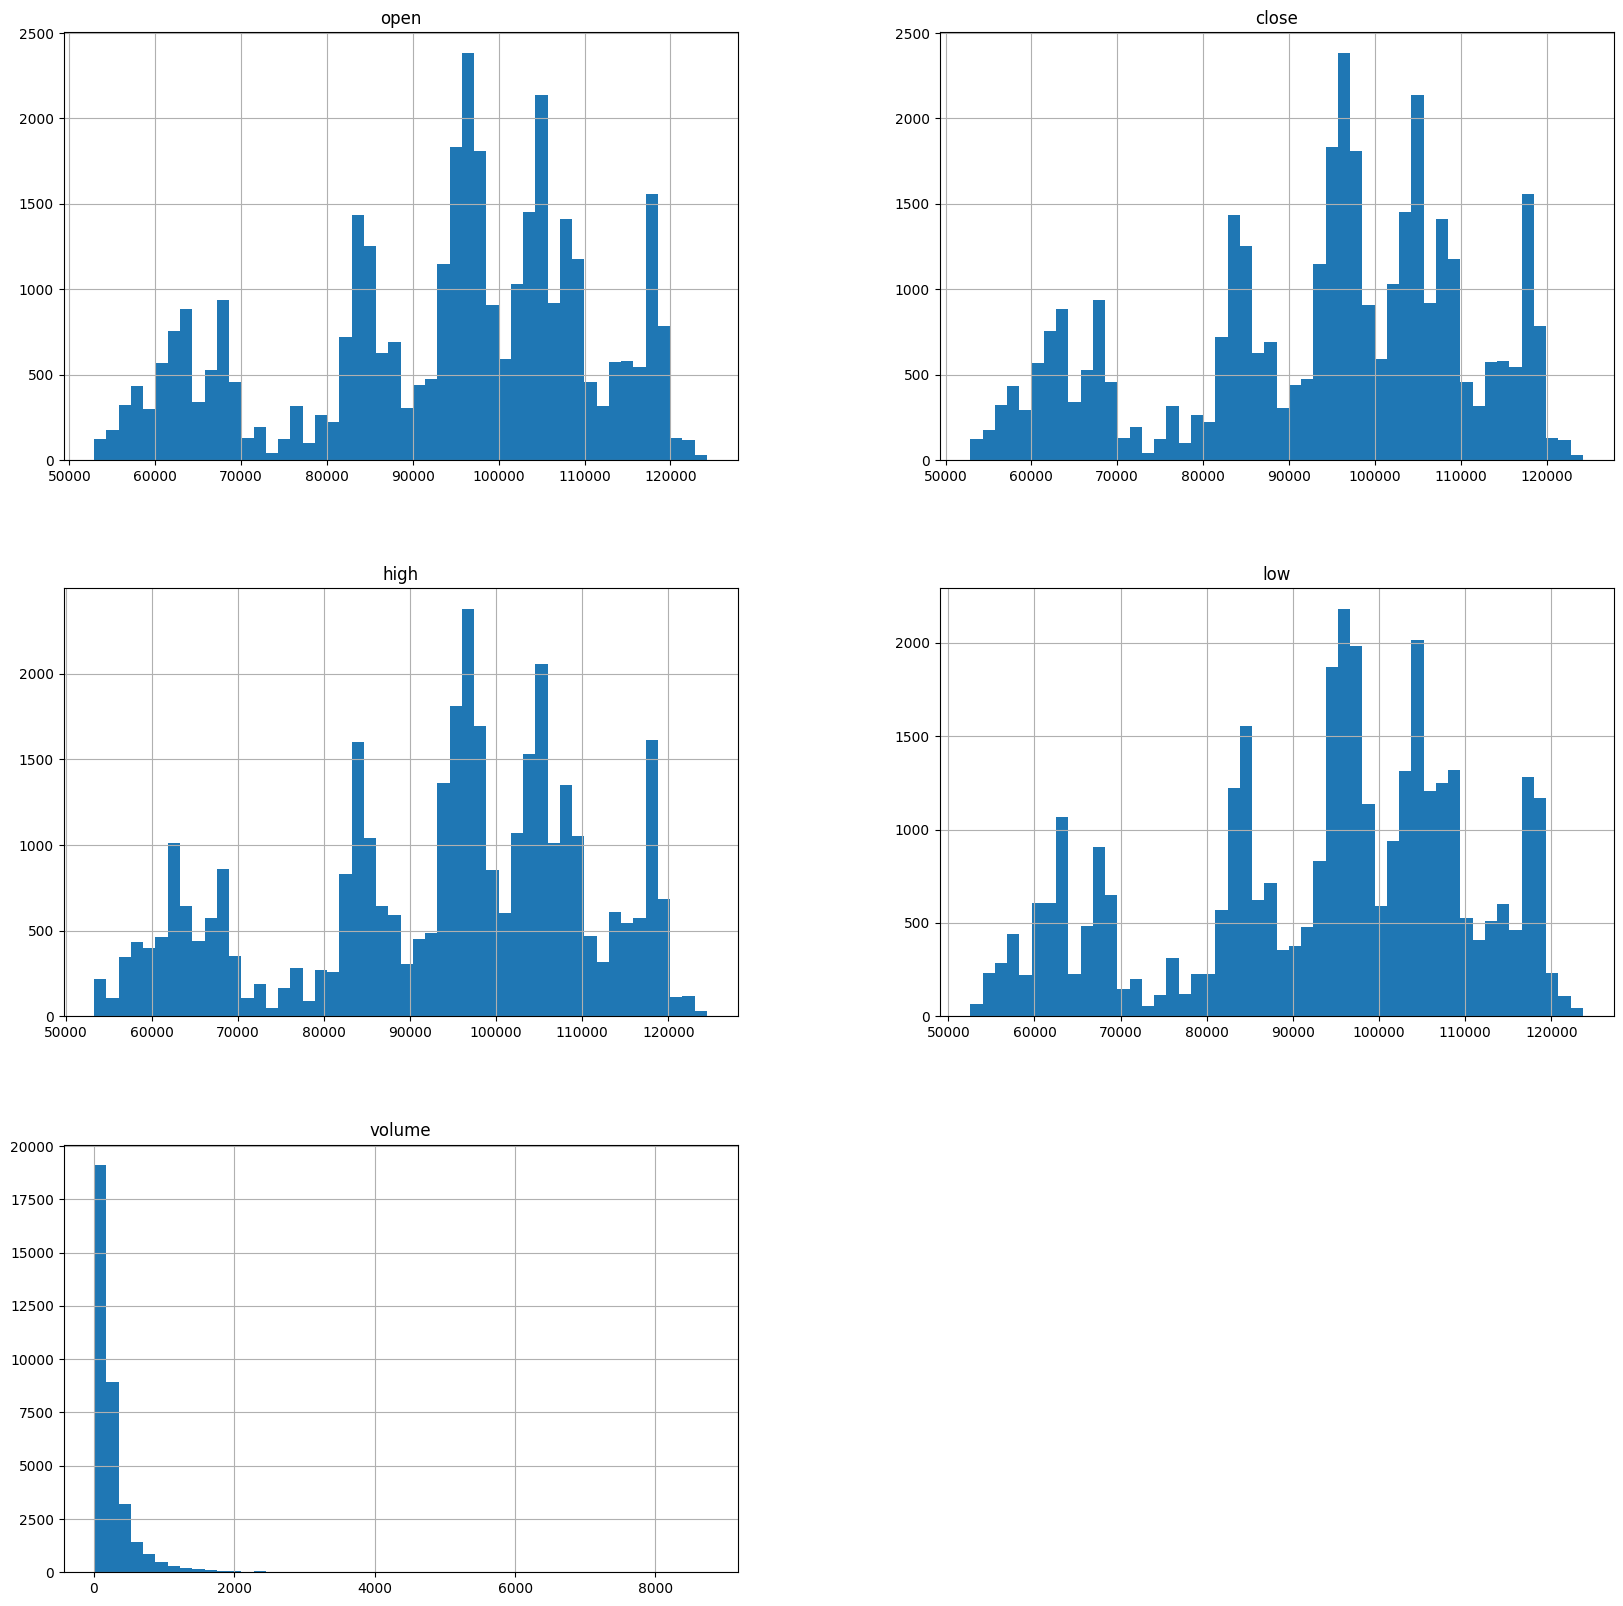

In [147]:
df[OCHLV].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font> I can say that Open, Close, High and Low share the same pattern. The exception is Volume. </font>

#### <font color="yellow"> MOMENTUM. </font>

In [148]:
df[MOMENTUM].describe()

,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
count,35007.000000,35031.000000,35015.000000,35007.000000,35007.000000,35015.000000,35007.000000,35007.000000,35028.000000,35027.000000,35014.000000,35027.000000,35025.000000,35003.000000
mean,21.573153,93386.076496,0.011937,0.000031,0.011938,-2.946785,-0.001215,-2.946164,0.025108,50.599714,0.506710,52.121274,52.122365,1.196017
std,635.620766,17162.696625,0.272842,0.082092,0.256966,17.485398,8.490026,14.686574,0.843481,11.124490,0.354274,29.013907,26.776355,18.954368
min,-3964.689735,53708.106727,-1.742898,-0.520475,-1.531201,-48.427842,-21.997736,-45.335848,-6.448699,7.479216,0.000000,0.000000,0.130745,-75.220688
25%,-252.641294,83730.257766,-0.105731,-0.037887,-0.099391,-15.340931,-5.713404,-13.270926,-0.339494,43.395262,0.177982,26.960476,28.265396,-11.394582
50%,23.983471,96555.499542,0.011186,-0.000457,0.011547,-4.748205,-1.093677,-3.639386,0.020562,50.735476,0.512567,53.444444,53.294461,1.336437
75%,305.890676,105503.660036,0.134483,0.038226,0.129523,7.458919,4.285745,6.624239,0.391361,57.928091,0.838001,77.559287,76.084756,13.656524
max,5907.463059,123204.907512,2.326518,0.909445,1.952636,76.785431,61.975881,53.696444,10.924205,89.928399,1.000000,100.000000,99.907398,70.194852


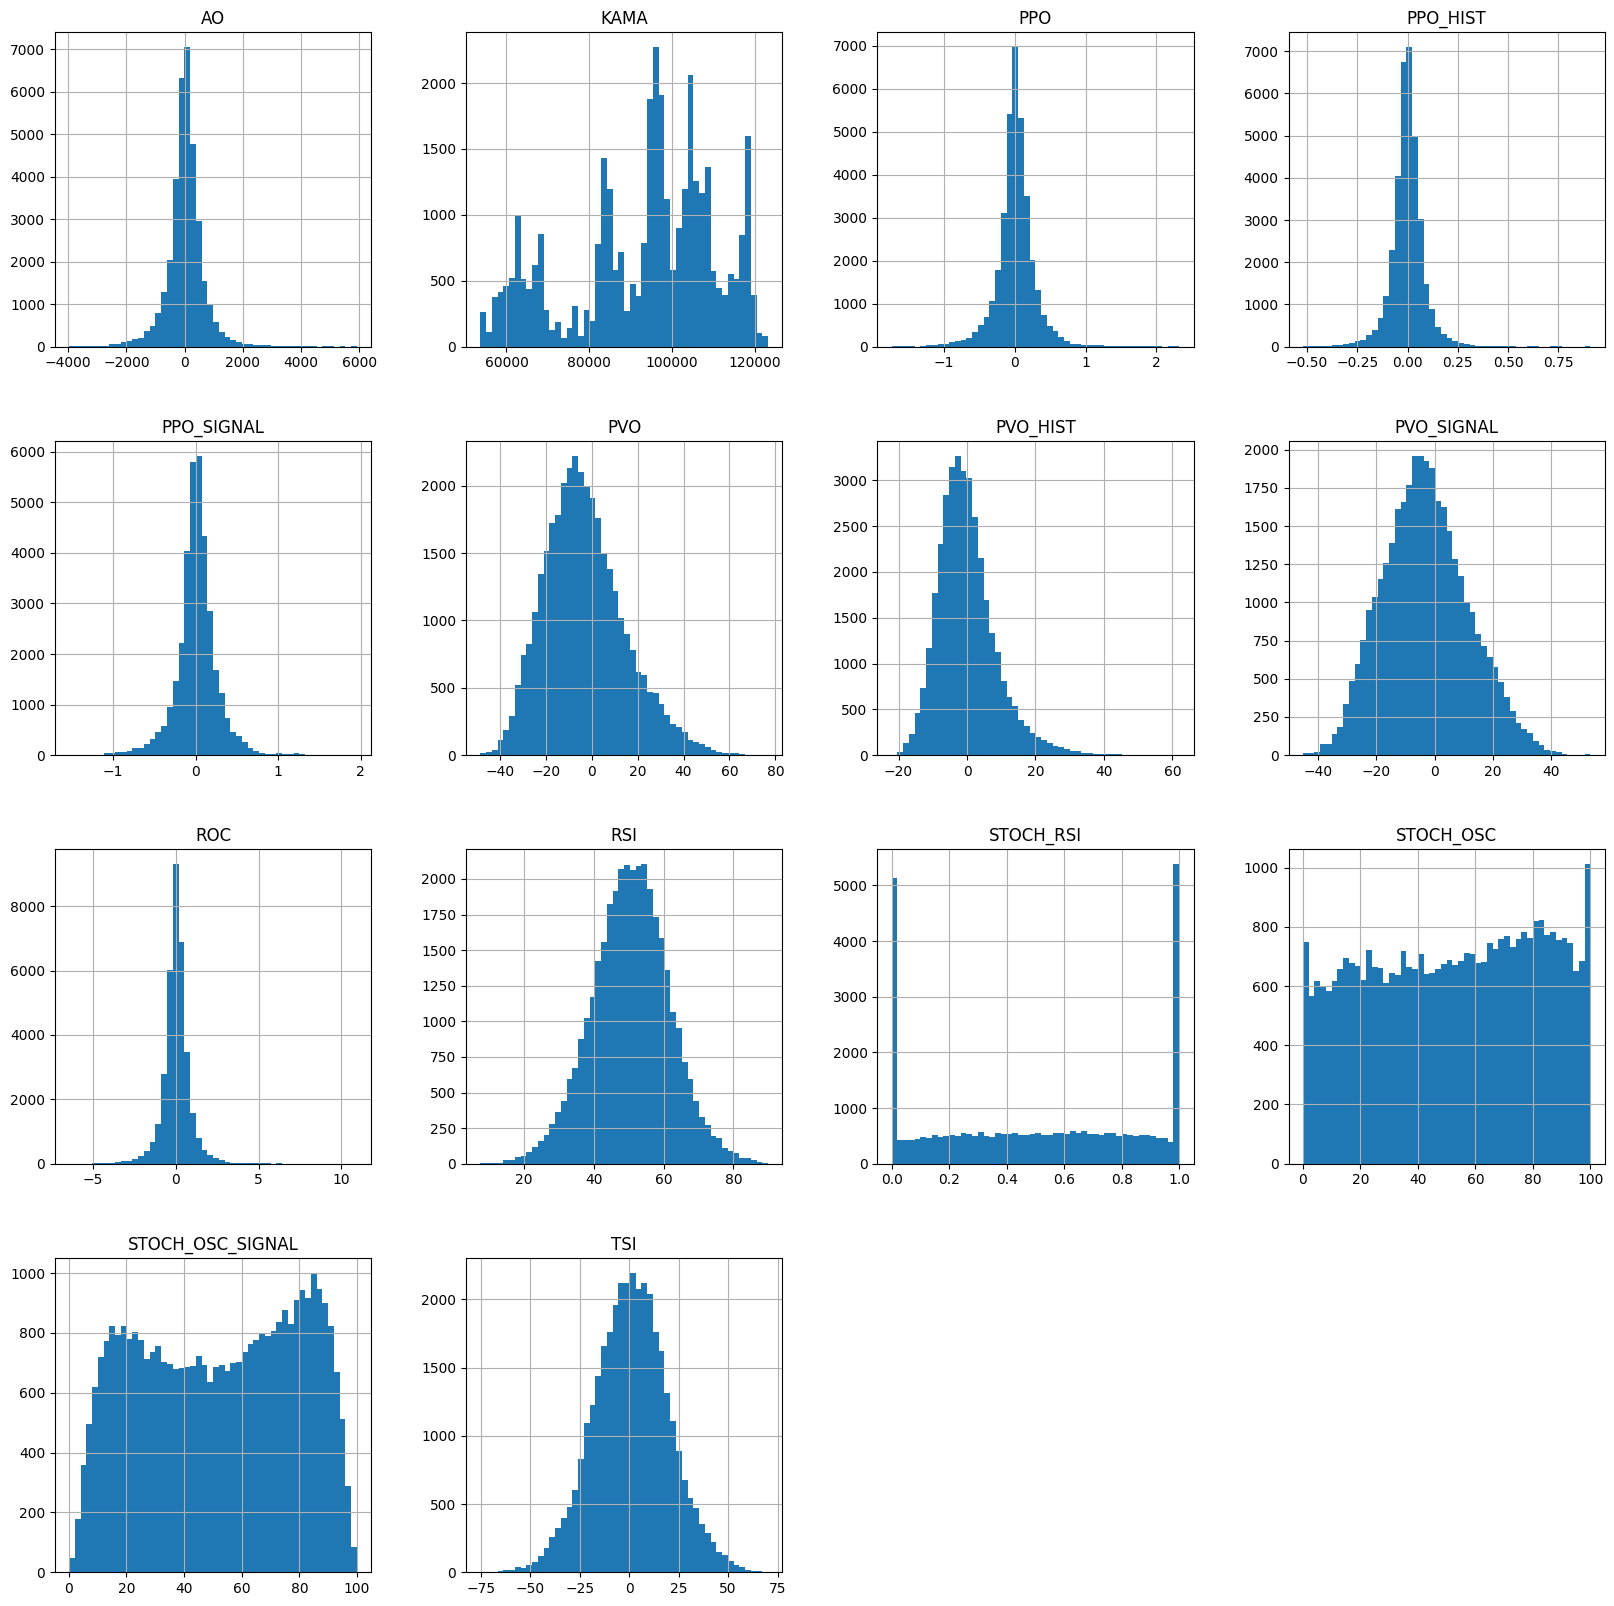

In [149]:
df[MOMENTUM].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow"> MOMENTUM. </font>
<font color="#5283fe">BELL</font>
<ol>
  <li>AO</li>
  <li>PPO</li>
  <li>PPO Hist</li>
  <li>PPO Signal</li>
  <li>PVO</li>
  <li>PVO Hist</li>
  <li>PVO Signal</li>
  <li>ROC</li>
  <li>RSI</li>
  <li>TSI</li>
</ol>
<p>Is the same pattern for these indicators, so there are posibilities that we can discard some of this indicators.</p>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>KAMA</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated.</p>

<font color="#5283fe">Other</font>
<ol>
  <li>STOCH RSI</li>
  <li>STOCH OSC</li>
  <li>STOCH OSC SIGNAL</li>
</ol>
<p>Need to understand how this works.</p>

#### <font color="yellow"> Volumen </font>

In [150]:
df[VOLUME].describe()

,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP
count,35040.000000,35021.000000,3.503900e+04,3.502600e+04,3.502700e+04,35027.000000,35040.000000,35040.000000,35039.000000,35027.000000
mean,123625.758124,0.011495,2.273792e+08,2.279444e+08,8.896787e+02,50.090314,2010.836542,46068.425601,334.112391,93384.544797
std,59252.504321,0.156883,2.467511e+10,6.727335e+09,1.154377e+05,17.868395,716.090790,34093.462413,243.334675,17160.507225
min,-10348.408972,-0.615983,-5.815276e+11,-5.372551e+10,-3.828752e+06,0.000000,981.741568,-30588.727060,-205.514683,53284.481149
25%,124326.646400,-0.094194,-1.043504e+10,-3.076860e+09,-6.076642e+03,36.877236,1284.516294,26238.881162,141.330266,83810.116649
50%,137252.166723,0.011634,1.141501e+08,2.377152e+08,1.673559e+02,50.118928,1868.321774,42753.593738,403.063215,96540.814467
75%,163191.437015,0.115829,1.056313e+10,3.510773e+09,6.800283e+03,63.210876,2834.555609,76661.817803,513.564265,105539.803801
max,195717.360760,0.676539,2.377418e+11,4.514740e+10,4.057538e+06,98.733114,3237.144219,123672.402033,885.635952,123726.791087


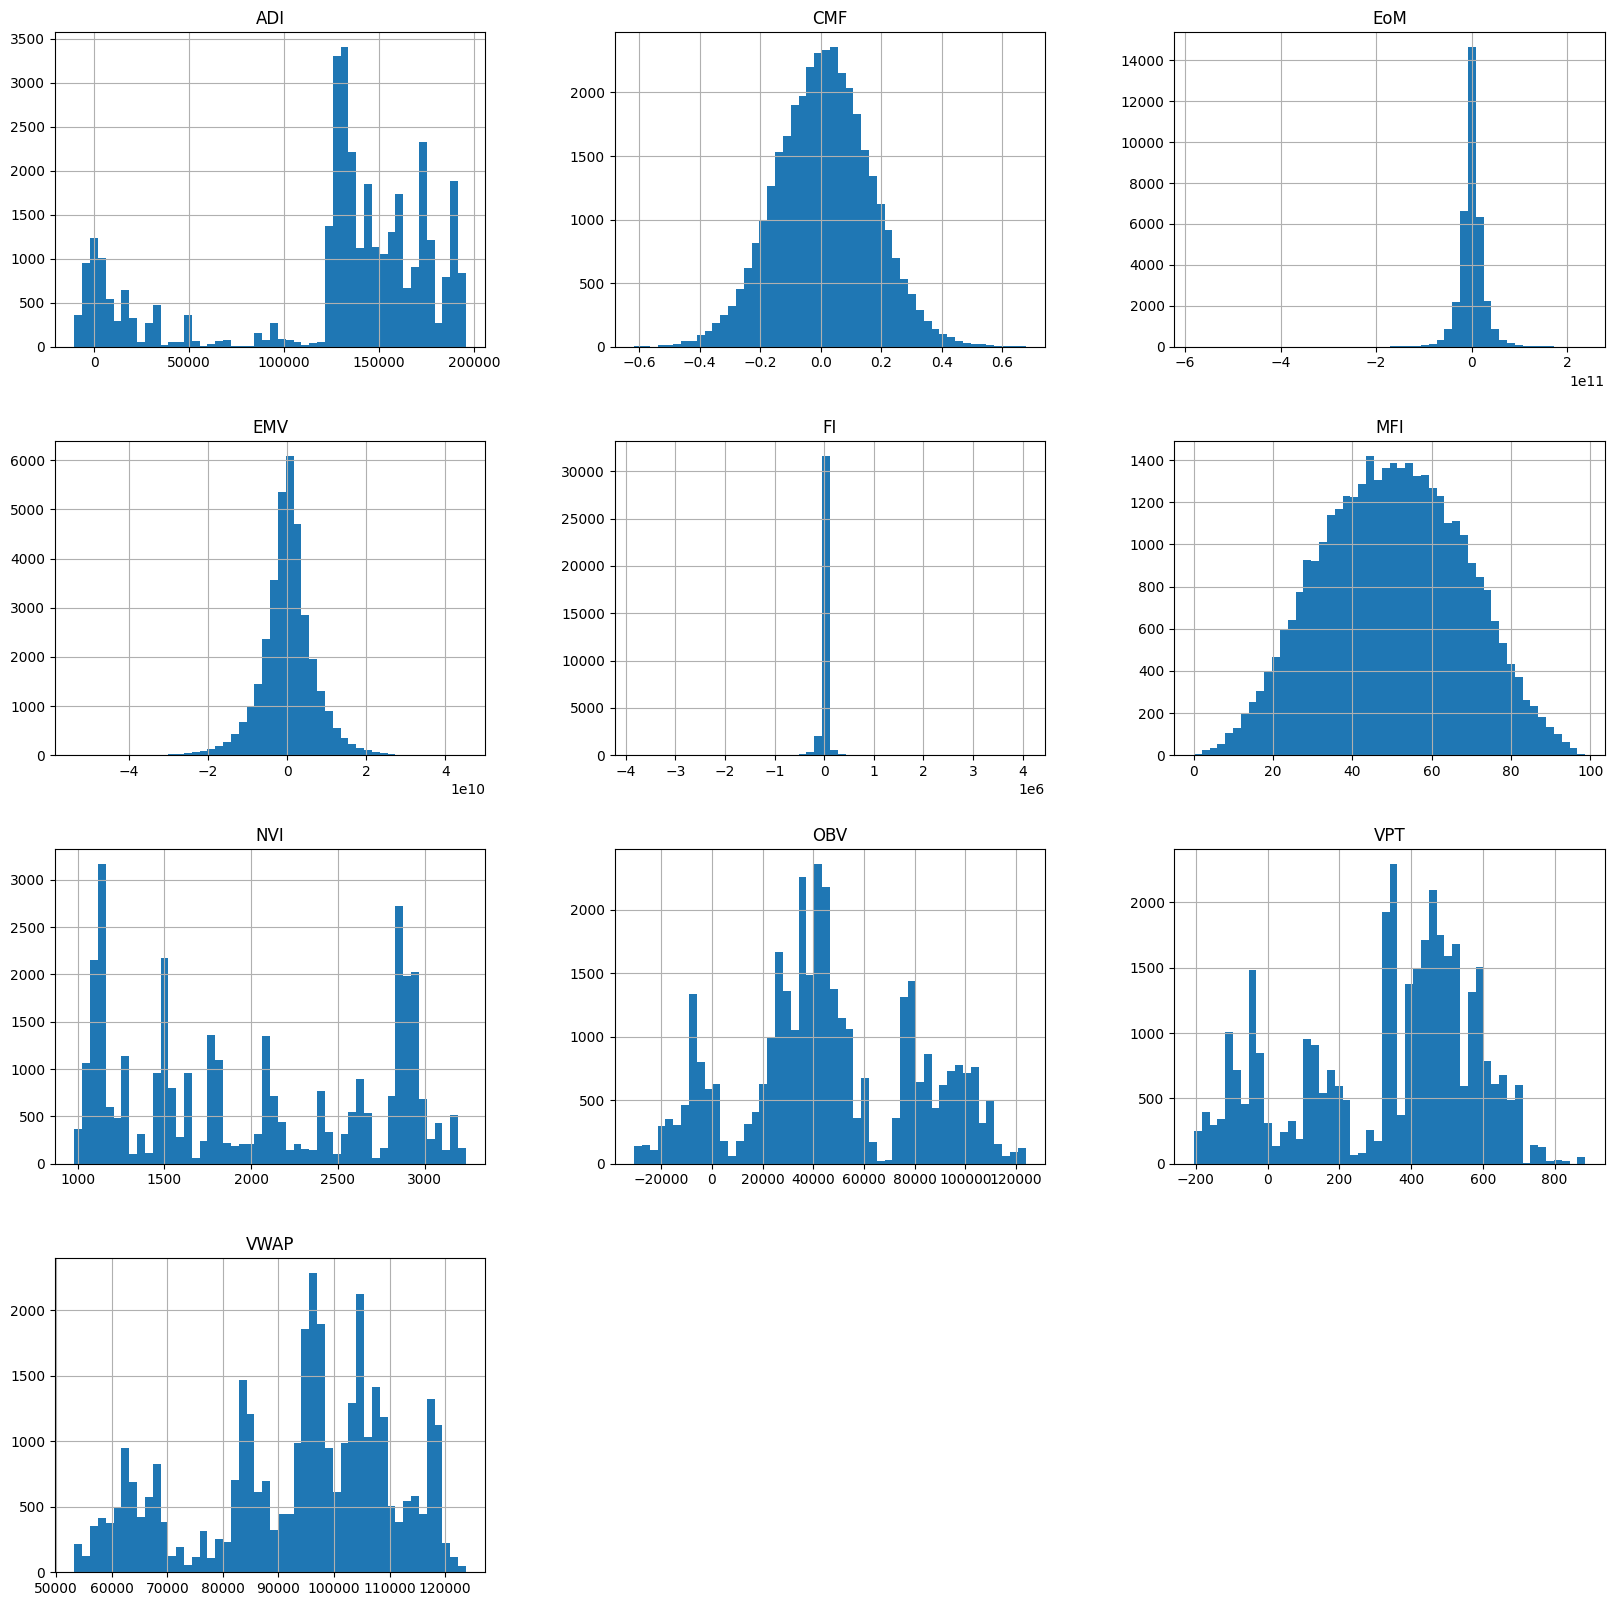

In [151]:
df[VOLUME].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow"> VOLUME </font>
<font color="#5283fe">BELL</font>
<ol>
  <li>CMF</li>
  <li>MFI</li>
  <li>EoM</li>
  <li>EMV</li>
  <li>FI</li>
</ol>
<p>Is the same pattern for these indicators, need the check the scale.</p>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>VWAP</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated.</p>

<font color="#5283fe">Unique Patterns</font>
<ol>
  <li>ADI</li>
  <li>NVI</li>
  <li>OBV</li>
  <li>VPT</li>
</ol>
<p>Need to understand how this works.</p>

####  <font color="yellow">VOLATILITY </font>

In [152]:
df[VOLATILITY].describe()

,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,...,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX
count,35040.000000,35021.000000,35040.000000,35021.000000,35040.000000,35021.000000,35021.000000,35021.000000,35021.000000,35021.000000,...,35021.000000,35021.000000,35040.000000,35040.000000,35040.000000,35040.000000,35021.000000,35040.000000,35021.000000,35027.000000
mean,288.622014,94026.888468,0.058390,92763.413319,0.059389,93395.150894,0.510799,1.375776,94070.221594,92672.017862,...,0.524161,1.524238,93663.765821,0.269235,93086.355246,0.242180,93393.532304,0.535183,0.629774,0.535417
std,154.968137,17215.053541,0.234484,17114.508050,0.236355,17157.131757,0.330605,1.120955,17210.674578,17108.337190,...,0.286942,1.075063,17191.849825,0.443569,17150.471212,0.428409,17156.696298,0.815365,0.364955,0.494636
min,0.000000,53995.363026,0.000000,52918.978123,0.000000,53569.950000,-0.528913,0.142631,53997.000000,52550.000000,...,0.000000,0.173211,53898.578500,0.000000,53189.318167,0.000000,53555.244167,-3.216477,0.055367,0.007338
25%,182.335869,84368.681405,0.000000,83148.147434,0.000000,83799.668000,0.250032,0.682540,84400.000000,83040.290000,...,0.276405,0.833250,84105.296792,0.000000,83456.214292,0.000000,83801.397000,0.019021,0.385075,0.226545
50%,255.212509,97143.173600,0.000000,95976.793734,0.000000,96569.130500,0.524405,1.045895,97200.700000,95800.000000,...,0.537627,1.220322,96820.902667,0.000000,96299.276833,0.000000,96568.459333,0.543788,0.544789,0.387862
75%,353.220623,106174.367054,0.000000,104987.128756,0.000000,105509.741500,0.771224,1.657392,106252.000000,104872.500000,...,0.776128,1.854977,105742.411458,1.000000,105289.666167,0.000000,105510.509333,1.044283,0.768217,0.658293
max,1749.980973,124306.002125,1.000000,123056.241095,1.000000,123555.717000,1.501067,15.228677,124474.000000,123116.100000,...,1.000000,11.277466,123911.171000,1.000000,123230.738667,1.000000,123561.387167,4.812792,3.136463,4.647333


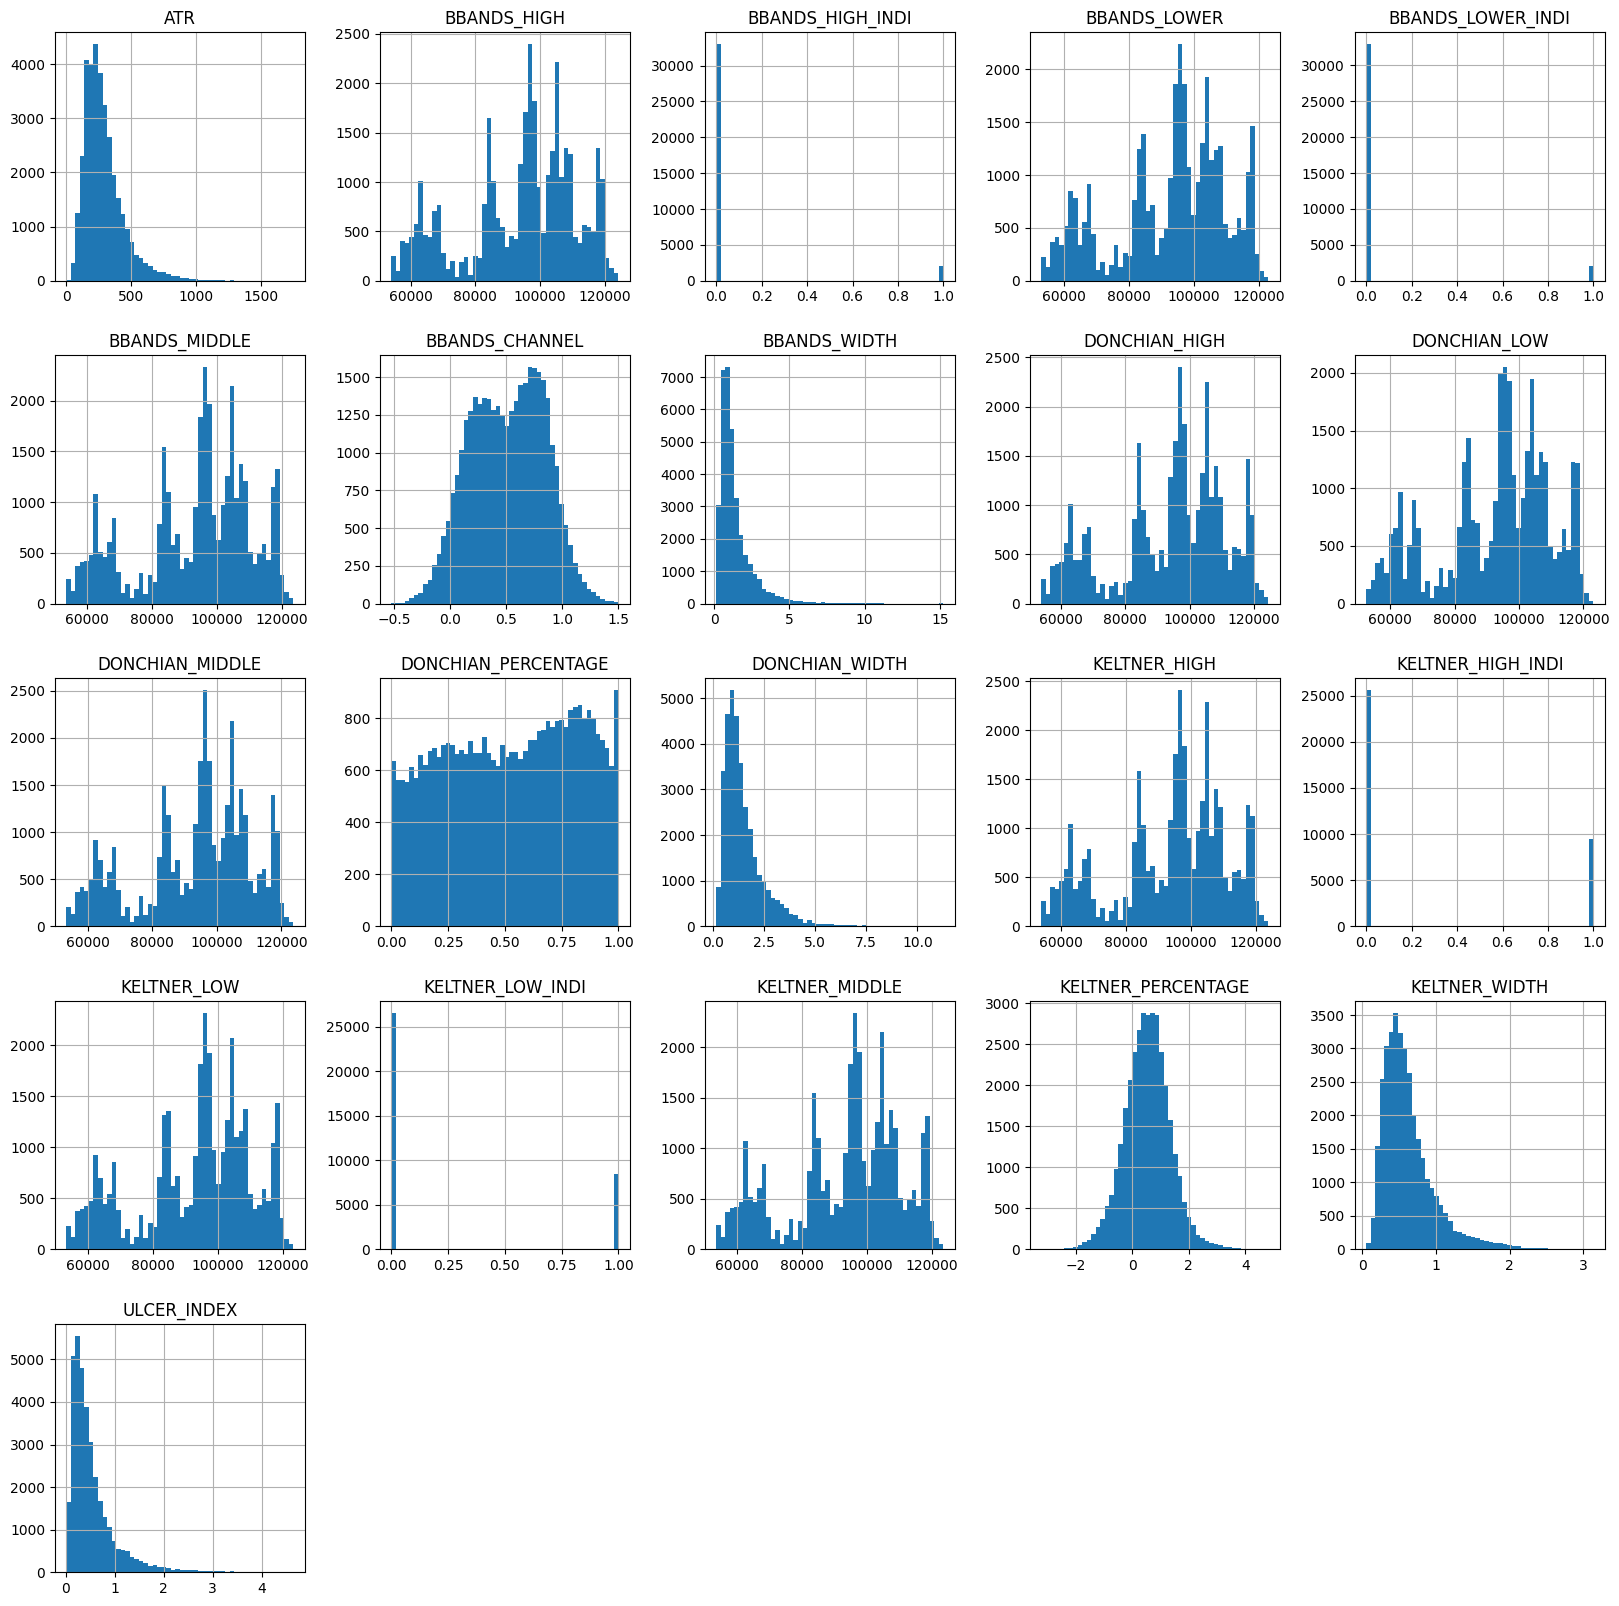

In [153]:
df[VOLATILITY].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow">VOLATILITY </font>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>BBANDS HIGH</li>
  <li>BBANDS LOWER</li>
  <li>BBANDS MIDDLE</li>
  <li>KELTNER HIGH</li>
  <li>KELTNER LOWER</li>
  <li>KELTNER MIDDLE</li>
  <li>DONCHIAN HIGH</li>
  <li>DONCHIAN LOWER</li>
  <li>DONCHIAN MIDDLE</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated. Also if they have the same porpouse probably im gonna need to chose one between Bolinger Bands, Keltner or Donchian.</p>

<font color="#5283fe">Indicators (0 or 1)</font>
<ol>
  <li>BBANDS HIGH INDI</li>
  <li>BBANDS LOWER INDI</li>
  <li>DONCHIAN HIGH INDI</li>
  <li>DONCHIAN LOWER INDI</li>
</ol>
<p>The same as before, need to choose one.</p>

<font color="#5283fe">Width</font>
<ol>
  <li>BBANDS Width</li>
  <li>DONCHIAN Width</li>
  <li>KELTNER Width</li>
  <li>ULCER INDEX</li>
  <li>ATR</li>
</ol>
<p>Need to understand how this works.</p>

#### <font color="yellow">TREND </font>

In [154]:
df[TREND].describe()

,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,...,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
count,35040.000000,35040.000000,35040.000000,35015.000000,35015.000000,35015.000000,35021.000000,35021.000000,35027.000000,35026.000000,...,35026.000000,35015.000000,35007.000000,35007.000000,35000.000000,35027.000000,35026.000000,35026.000000,35026.000000,35027.000000
mean,25.131197,21.555168,21.583803,47.985035,46.236070,1.748965,3.683259,-2.248242,93393.760433,0.316882,...,0.038672,10.366571,10.360334,0.026346,24.924366,93393.752914,1.009123,0.992486,0.016637,93396.966429
std,10.506718,7.646380,7.333498,35.421644,35.411434,60.498286,112.174342,299.732330,17159.167755,10.900101,...,3.205249,250.305625,235.676529,75.476011,1.790095,17160.811003,0.164361,0.160760,0.320185,17159.881371
min,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,-542.978684,-3439.470000,53543.541888,-347.686399,...,-18.985339,-1543.722834,-1358.673480,-547.233351,18.994832,53486.857143,0.428274,0.260890,-1.069625,53419.344667
25%,17.243519,16.207011,16.439528,12.000000,12.000000,-52.000000,-81.365246,-137.650500,83821.248420,-3.600092,...,-1.386913,-96.901467,-92.291705,-34.744282,23.605968,83819.516071,0.896148,0.884255,-0.207900,83825.150810
50%,23.207879,20.897058,20.999168,48.000000,44.000000,8.000000,8.073064,0.169500,96570.880487,0.367765,...,-0.000255,10.360746,10.356821,-0.273737,24.763418,96574.905000,1.010280,0.996821,0.014665,96577.009238
75%,31.071556,26.193122,26.136110,84.000000,80.000000,56.000000,88.113998,135.352500,105514.760650,4.605121,...,1.396787,124.382178,119.164043,35.298720,26.179890,105517.034286,1.123916,1.105419,0.238162,105528.042429
max,68.448844,72.465025,65.360835,100.000000,100.000000,100.000000,478.440193,2698.653500,123515.159154,79.976999,...,66.777728,2080.738878,1753.019765,825.912095,32.398739,123646.237857,1.671132,1.622736,1.384541,123617.738762


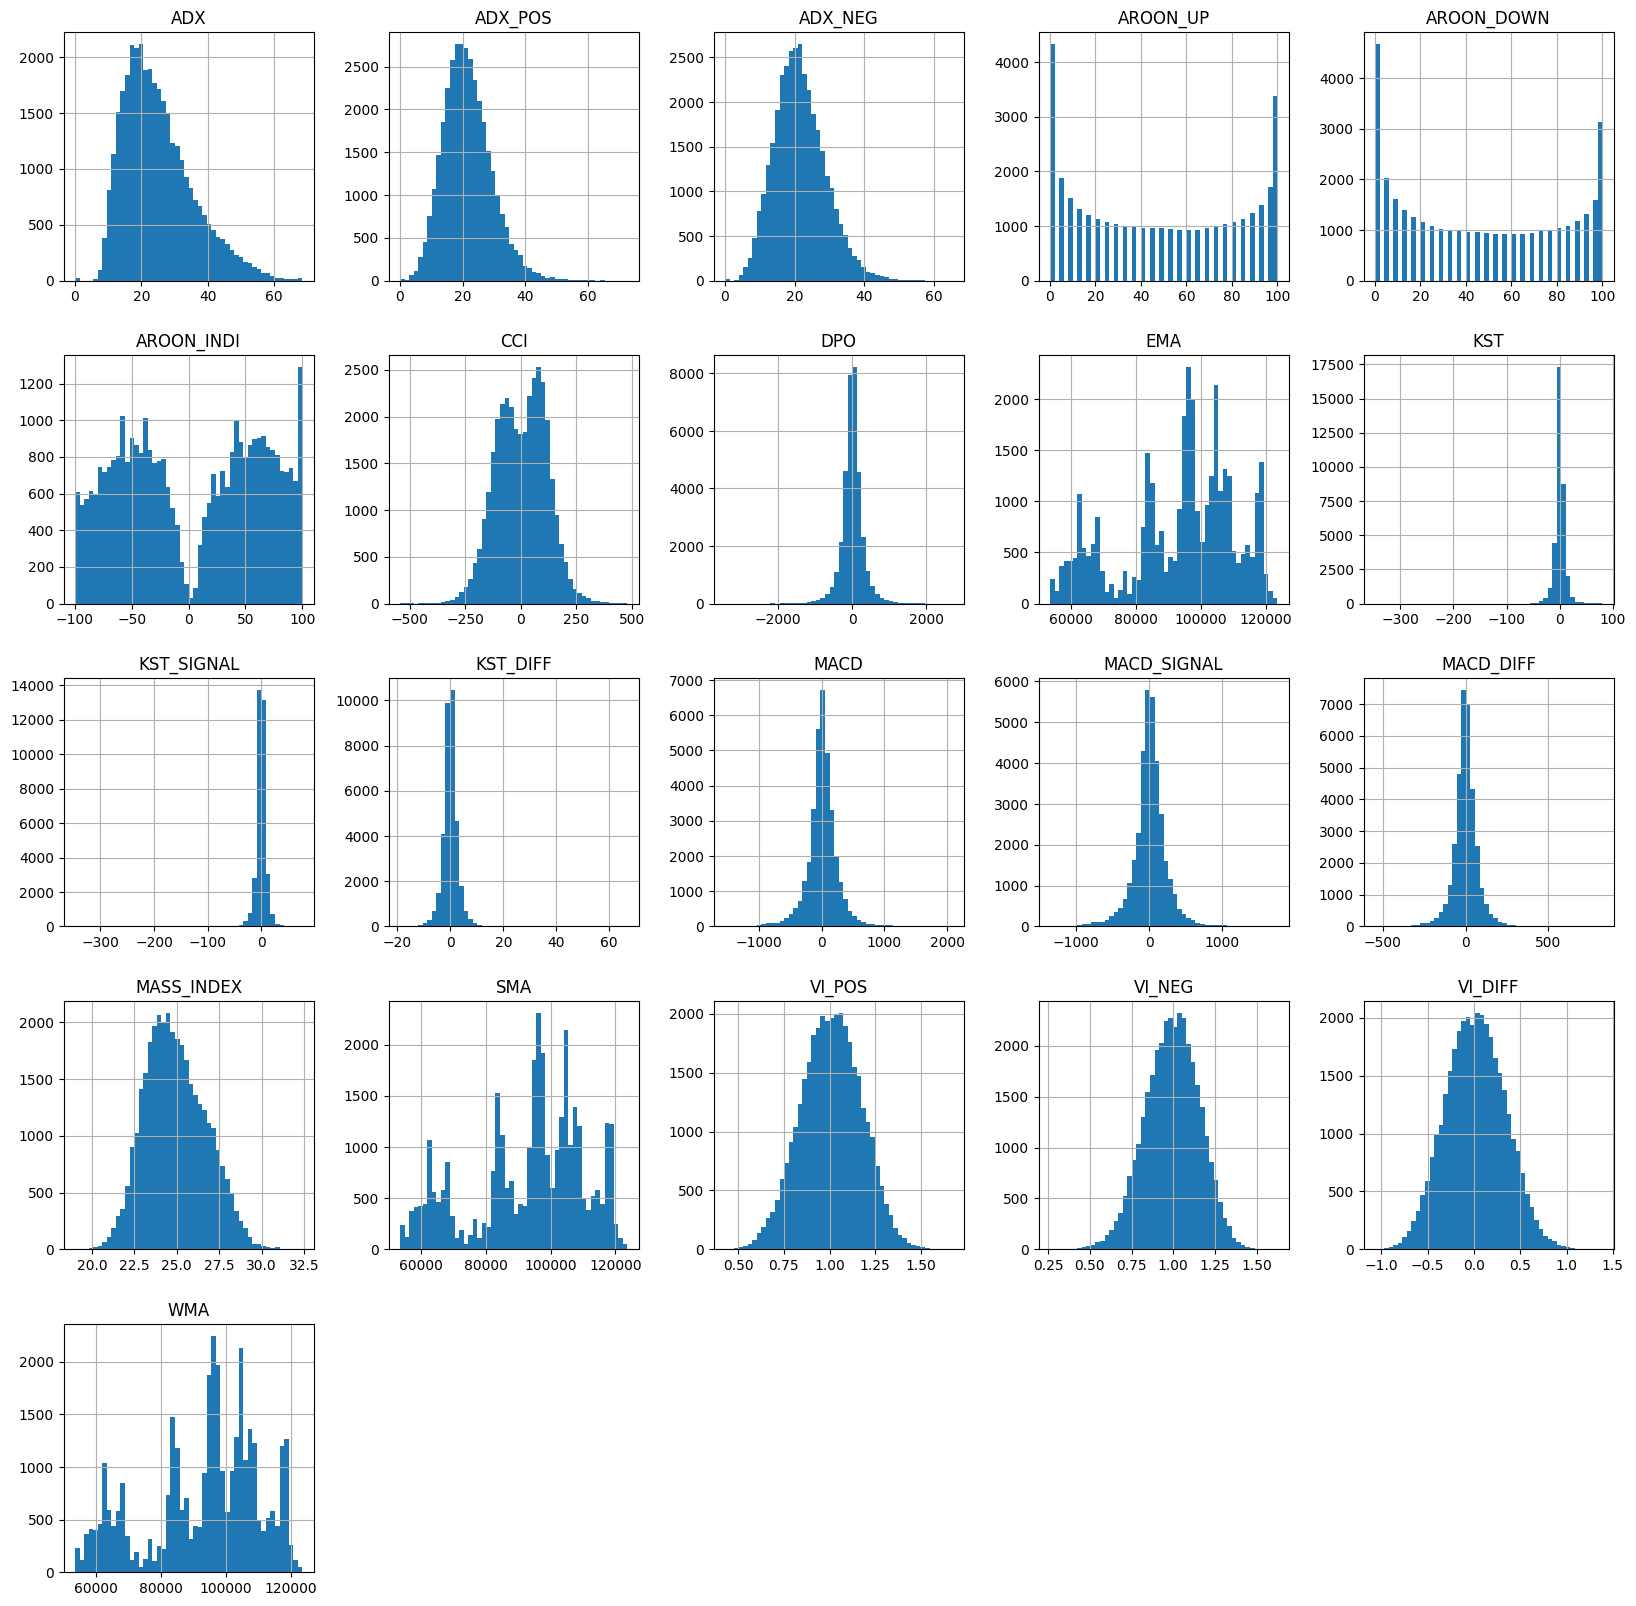

In [155]:
df[TREND].hist(figsize=(20, 20), bins=50)
plt.show()

##### <font color="yellow">TREND </font>

<font color="#5283fe">Same as Open, Close, High and Low</font>
<ol>
  <li>VMA</li>
  <li>SMA</li>
  <li>EMA</li>
</ol>
<p>This indicator has the same pattern as OHCL, so there are possibilities that they are correlated. Also if they have the same porpouse probably im gonna need to chose one and discard the others.</p>

<font color="#5283fe">BELL</font>
<ol>
  <li>ADX</li>
  <li>CCI</li>
  <li>DPO</li>
  <li>KST</li>
  <li>MACD</li>
  <li>MASS</li>
  <li>VI</li>
</ol>
<p>The same as before, need to choose one.</p>

<font color="#5283fe">Aroon</font>
<ol>
  <li>AROON UP</li>
  <li>AROON DOWN</li>
  <li>AROON INDICATOR</li>
</ol>
<p>Need to understand how this works.</p>

# Explore Data

In [156]:
velas = df.copy()

### Look for correlations

##### OCHLV

In [157]:
velas[OCHLV].corr()

,open,close,high,low,volume
open,1.000000,0.999912,0.999948,0.999941,-0.106202
close,0.999912,1.000000,0.999952,0.999948,-0.106119
high,0.999948,0.999952,1.000000,0.999902,-0.100773
low,0.999941,0.999948,0.999902,1.000000,-0.112014
volume,-0.106202,-0.106119,-0.100773,-0.112014,1.000000


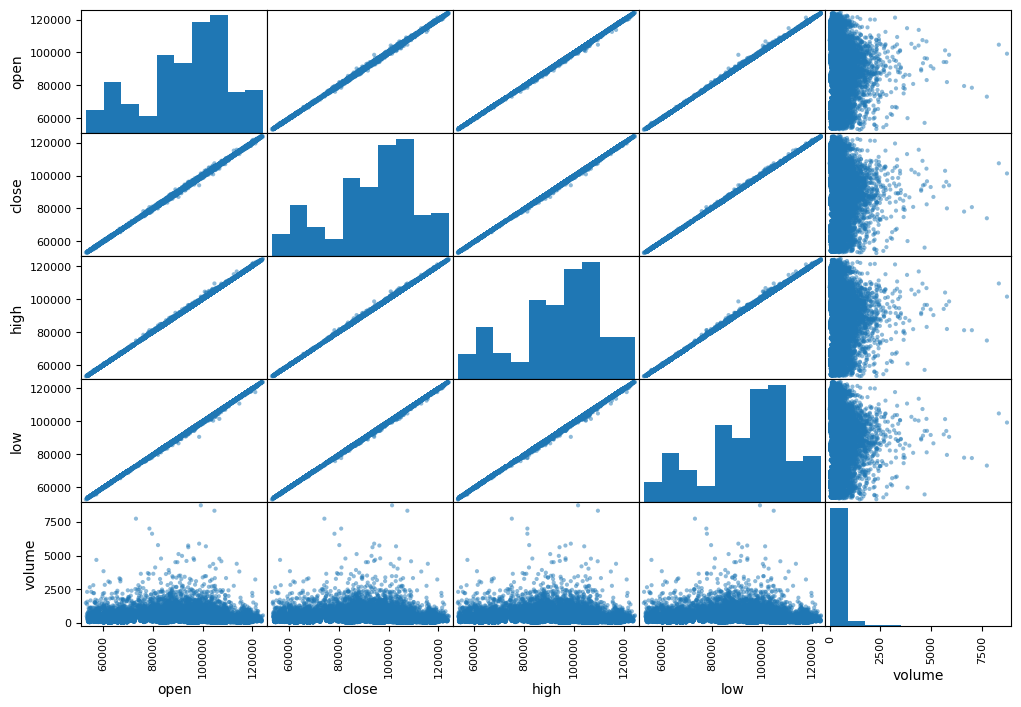

In [158]:
scatter_matrix(velas[OCHLV], figsize=(12, 8))
plt.show()

#### OCHLV with Momentum

In [159]:
VOLUME = ["ADI", "CMF", "EoM", "EMV", "FI", "MFI", "NVI", "OBV", "VPT", "VWAP"]
VOLATILITY = ["ATR", "BBANDS_HIGH", "BBANDS_HIGH_INDI", "BBANDS_LOWER", "BBANDS_LOWER_INDI", "BBANDS_MIDDLE", "BBANDS_CHANNEL", "BBANDS_WIDTH", "DONCHIAN_HIGH", "DONCHIAN_LOW", "DONCHIAN_MIDDLE", "DONCHIAN_PERCENTAGE", "DONCHIAN_WIDTH", "KELTNER_HIGH", "KELTNER_HIGH_INDI", "KELTNER_LOW", "KELTNER_LOW_INDI", "KELTNER_MIDDLE", "KELTNER_PERCENTAGE", "KELTNER_WIDTH", "ULCER_INDEX"]
TREND = ["ADX", "ADX_POS", "ADX_NEG", "AROON_UP", "AROON_DOWN", "AROON_INDI", "CCI", "DPO", "EMA", "KST", "KST_SIGNAL", "KST_DIFF", "MACD", "MACD_SIGNAL", "MACD_DIFF", "MASS_INDEX", "SMA", "VI_POS", "VI_NEG", "VI_DIFF", "WMA"]

In [160]:
MOMENTUM_INDIVIDUALS = ["AO", "KAMA", "ROC", "RSI", "TSI"]
MOMENTUM_PPO = ["PPO", "PPO_HIST", "PPO_SIGNAL"]
MOMENTUM_PVO = ["PVO", "PVO_HIST", "PVO_SIGNAL"]
MOMENTUM_STOCH = ["STOCH_RSI", "STOCH_OSC", "STOCH_OSC_SIGNAL"]

##### Individuals

In [161]:
velas[OCHLV+MOMENTUM_INDIVIDUALS].corr()

,open,close,high,low,volume,AO,KAMA,ROC,RSI,TSI
open,1.000000,0.999912,0.999948,0.999941,-0.106202,0.015689,0.999810,0.001731,0.002705,0.007827
close,0.999912,1.000000,0.999952,0.999948,-0.106119,0.016041,0.999753,0.005448,0.007223,0.008727
high,0.999948,0.999952,1.000000,0.999902,-0.100773,0.015504,0.999783,0.003363,0.004775,0.007996
low,0.999941,0.999948,0.999902,1.000000,-0.112014,0.016608,0.999749,0.004393,0.005772,0.008924
volume,-0.106202,-0.106119,-0.100773,-0.112014,1.000000,-0.007382,-0.105106,-0.010684,-0.009432,0.002431
AO,0.015689,0.016041,0.015504,0.016608,-0.007382,1.000000,0.003714,0.730262,0.745352,0.867054
KAMA,0.999810,0.999753,0.999783,0.999749,-0.105106,0.003714,1.000000,-0.011072,-0.010034,-0.003149
ROC,0.001731,0.005448,0.003363,0.004393,-0.010684,0.730262,-0.011072,1.000000,0.771681,0.632612
RSI,0.002705,0.007223,0.004775,0.005772,-0.009432,0.745352,-0.010034,0.771681,1.000000,0.862074
TSI,0.007827,0.008727,0.007996,0.008924,0.002431,0.867054,-0.003149,0.632612,0.862074,1.000000


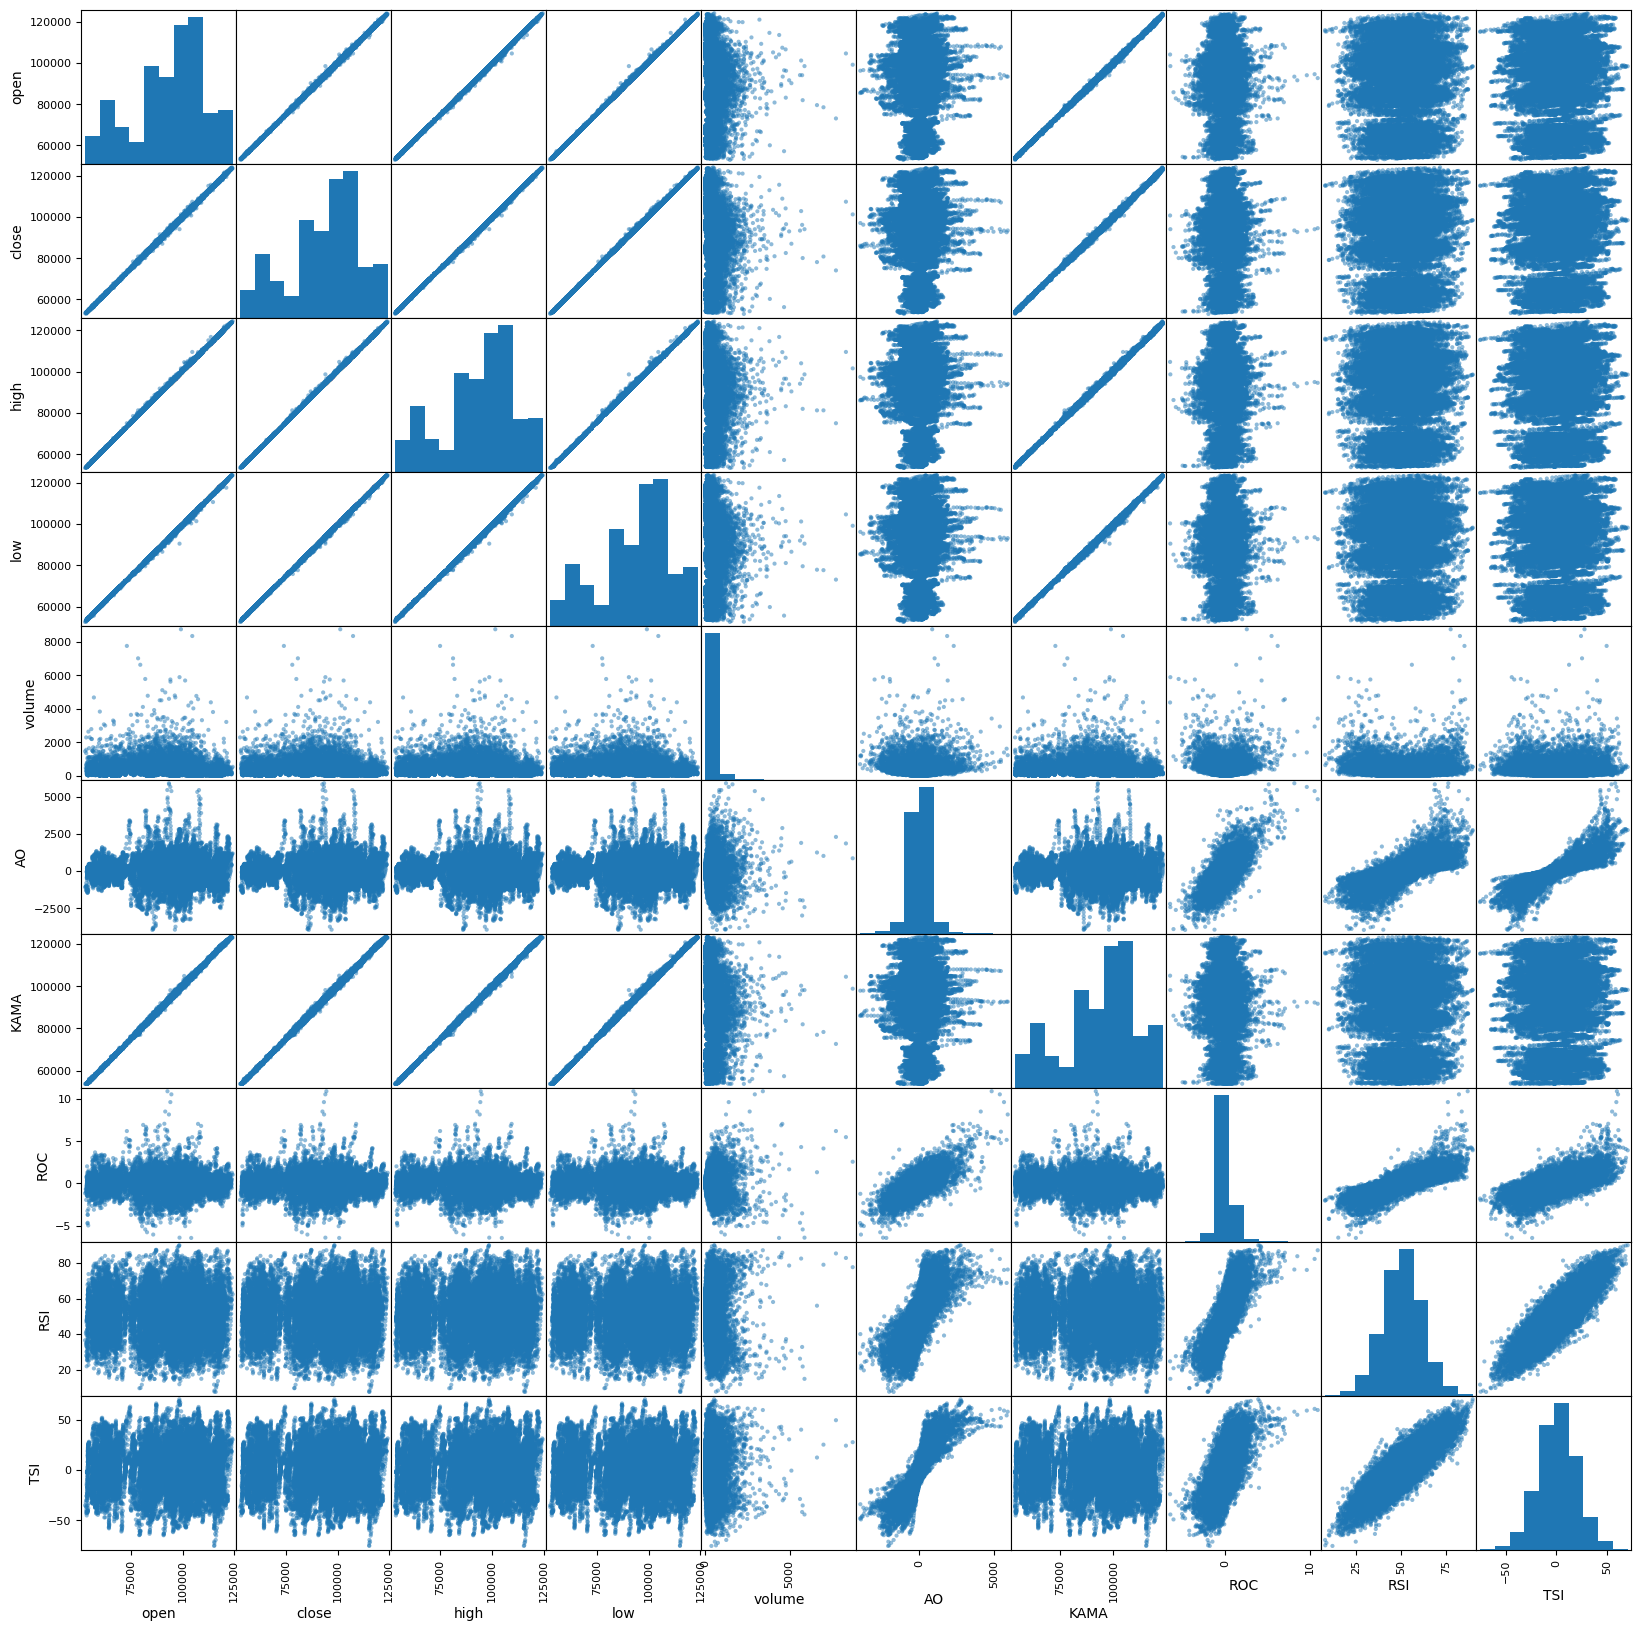

In [162]:
scatter_matrix(velas[OCHLV+MOMENTUM_INDIVIDUALS], figsize=(20, 20))
plt.show()

##### KAMA is related with OCHL, so probably is a good candidate to be in the model as an attribute. AO, TSI, RSI and ROC are correlated, WHY? All four indicators — AO, RSI, TSI, and ROC — are derived from price data, usually close, high, low, or combinations (like median price). That means: They are functions of the same underlying data (OHLCV). Their goal is to measure momentum, just with different math.

##### PPO

In [163]:
velas[OCHLV+MOMENTUM_PPO].corr()

,open,close,high,low,volume,PPO,PPO_HIST,PPO_SIGNAL
open,1.000000,0.999912,0.999948,0.999941,-0.106202,0.009091,-0.001890,0.010005
close,0.999912,1.000000,0.999952,0.999948,-0.106119,0.009945,0.000538,0.010137
high,0.999948,0.999952,1.000000,0.999902,-0.100773,0.009124,-0.000827,0.009701
low,0.999941,0.999948,0.999902,1.000000,-0.112014,0.010227,-0.000070,0.010631
volume,-0.106202,-0.106119,-0.100773,-0.112014,1.000000,0.003596,-0.025424,0.011914
PPO,0.009091,0.009945,0.009124,0.010227,0.003596,1.000000,0.338440,0.953746
PPO_HIST,-0.001890,0.000538,-0.000827,-0.000070,-0.025424,0.338440,1.000000,0.039912
PPO_SIGNAL,0.010005,0.010137,0.009701,0.010631,0.011914,0.953746,0.039912,1.000000


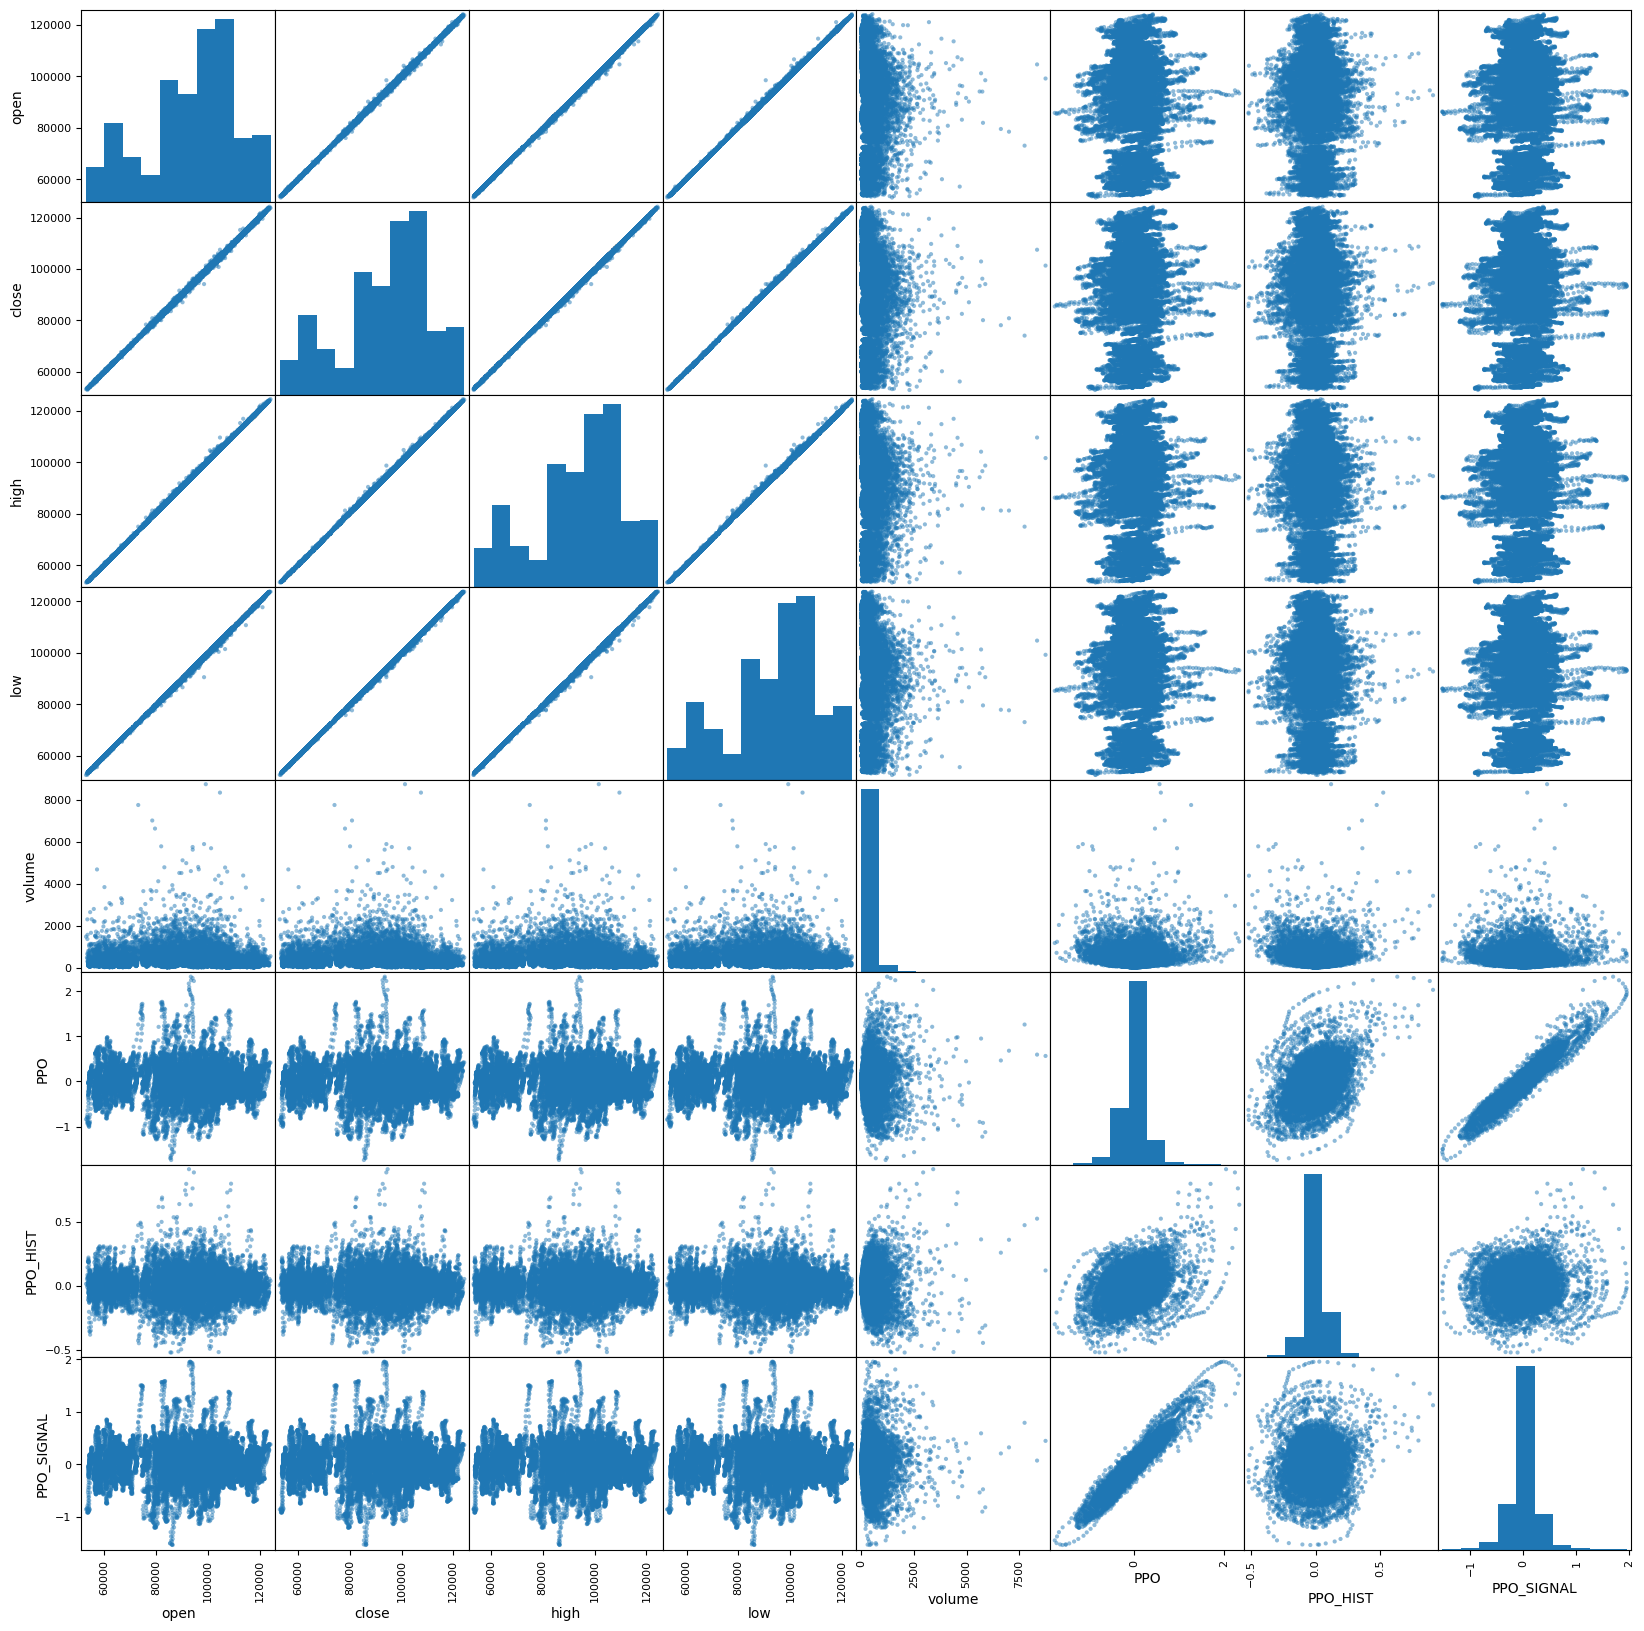

In [164]:
scatter_matrix(velas[OCHLV+MOMENTUM_PPO], figsize=(20, 20))
plt.show()

##### PVO

In [165]:
velas[OCHLV+MOMENTUM_PVO].corr()

,open,close,high,low,volume,PVO,PVO_HIST,PVO_SIGNAL
open,1.000000,0.999912,0.999948,0.999941,-0.106202,0.002736,0.000194,0.003229
close,0.999912,1.000000,0.999952,0.999948,-0.106119,0.002707,0.000181,0.003202
high,0.999948,0.999952,1.000000,0.999902,-0.100773,0.005573,0.002338,0.005369
low,0.999941,0.999948,0.999902,1.000000,-0.112014,-0.000273,-0.002133,0.000989
volume,-0.106202,-0.106119,-0.100773,-0.112014,1.000000,0.505621,0.421952,0.358122
PVO,0.002736,0.002707,0.005573,-0.000273,0.505621,1.000000,0.546202,0.874940
PVO_HIST,0.000194,0.000181,0.002338,-0.002133,0.421952,0.546202,1.000000,0.072275
PVO_SIGNAL,0.003229,0.003202,0.005369,0.000989,0.358122,0.874940,0.072275,1.000000


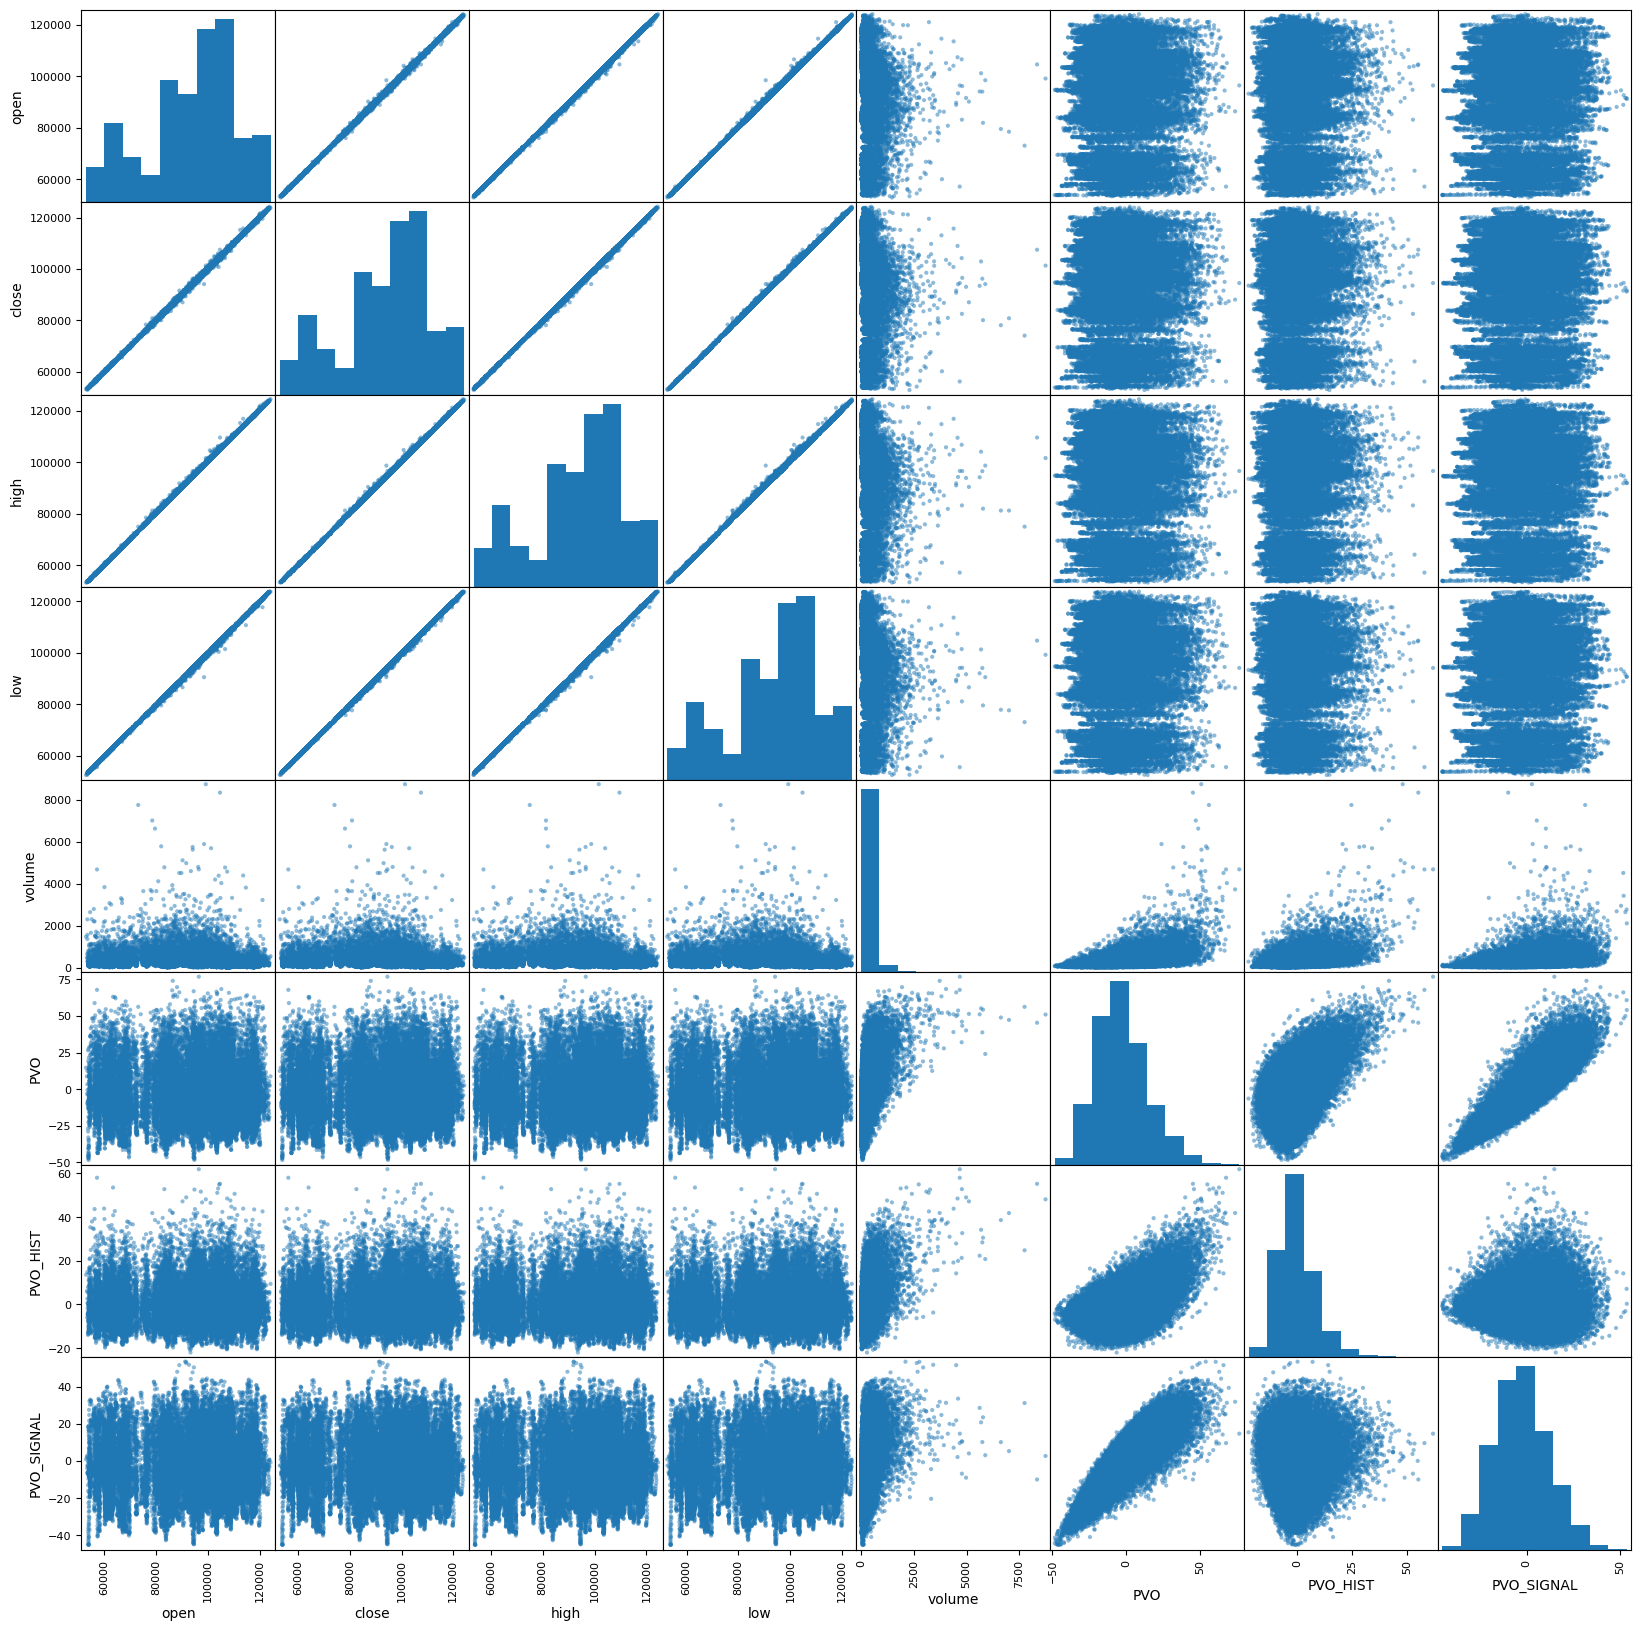

In [166]:
scatter_matrix(velas[OCHLV+MOMENTUM_PVO], figsize=(20, 20))
plt.show()

##### STOCH

In [167]:
velas[OCHLV+MOMENTUM_STOCH].corr()

,open,close,high,low,volume,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL
open,1.000000,0.999912,0.999948,0.999941,-0.106202,-0.009032,0.000892,0.004683
close,0.999912,1.000000,0.999952,0.999948,-0.106119,-0.003264,0.006189,0.006496
high,0.999948,0.999952,1.000000,0.999902,-0.100773,-0.006023,0.003283,0.005366
low,0.999941,0.999948,0.999902,1.000000,-0.112014,-0.005827,0.003919,0.006081
volume,-0.106202,-0.106119,-0.100773,-0.112014,1.000000,-0.011824,-0.018208,-0.017917
STOCH_RSI,-0.009032,-0.003264,-0.006023,-0.005827,-0.011824,1.000000,0.809641,0.651794
STOCH_OSC,0.000892,0.006189,0.003283,0.003919,-0.018208,0.809641,1.000000,0.906733
STOCH_OSC_SIGNAL,0.004683,0.006496,0.005366,0.006081,-0.017917,0.651794,0.906733,1.000000


In [168]:
scatter_matrix(velas[OCHLV+MOMENTUM_STOCH], figsize=(20, 20))
plt.show()

KeyboardInterrupt: 

##### Only MOMENTUM

In [ ]:
velas[MOMENTUM].corr()

,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI
AO,1.000000,0.003724,0.959257,0.449775,0.874918,-0.054378,-0.006333,-0.061087,0.730270,0.745340,0.043175,0.426115,0.531429,0.867067
KAMA,0.003724,1.000000,-0.002340,-0.014039,0.001751,0.004164,0.000679,0.004596,-0.011035,-0.009933,-0.015736,-0.009821,-0.008415,-0.003279
PPO,0.959257,-0.002340,1.000000,0.338449,0.953746,-0.045009,0.000809,-0.054052,0.700786,0.758753,0.012085,0.402629,0.487068,0.892467
PPO_HIST,0.449775,-0.014039,0.338449,1.000000,0.039922,-0.050583,-0.045026,-0.034201,0.826151,0.566314,0.593185,0.643880,0.692394,0.311092
PPO_SIGNAL,0.874918,0.001751,0.953746,0.039922,1.000000,-0.031627,0.015244,-0.046470,0.480204,0.624783,-0.176679,0.221811,0.295975,0.848296
PVO,-0.054378,0.004164,-0.045009,-0.050583,-0.031627,1.000000,0.546217,0.874952,-0.051409,-0.051525,-0.030102,-0.068011,-0.077814,-0.043185
PVO_HIST,-0.006333,0.000679,0.000809,-0.045026,0.015244,0.546217,1.000000,0.072319,-0.032818,-0.018458,-0.039431,-0.049052,-0.049587,0.003984
PVO_SIGNAL,-0.061087,0.004596,-0.054052,-0.034201,-0.046470,0.874952,0.072319,1.000000,-0.042223,-0.050642,-0.012985,-0.052584,-0.063967,-0.053724
ROC,0.730270,-0.011035,0.700786,0.826151,0.480204,-0.051409,-0.032818,-0.042223,1.000000,0.771672,0.472358,0.678273,0.704465,0.632605
RSI,0.745340,-0.009933,0.758753,0.566314,0.624783,-0.051525,-0.018458,-0.050642,0.771672,1.000000,0.490815,0.790020,0.784879,0.862066


###

### Candlestick chart

In [ ]:
import plotly.graph_objects as go
dataset = df.sort_values('timestamp')

# Create candlestick figure
fig = go.Figure(data=[
    go.Candlestick(
        x=dataset['timestamp'],
        open=dataset['open'],
        high=dataset['high'],
        low=dataset['low'],
        close=dataset['close'],
        name='OHLC'
    )
])

# Add layout options
fig.update_layout(
    title='Interactive Candlestick Chart',
    xaxis_title='Timestamp',
    yaxis_title='Price',
    xaxis_rangeslider_visible=False,
    template='plotly_dark',
    height=600
)

fig.write_html("candlestick_chart.html", auto_open=True)

### Line Chart fot the target labels

In [ ]:


def plot_line_chart(dataset, timestamp, columns):
    for column in columns:
        sns.lineplot(x=timestamp, y=column, data=dataset)
        plt.gcf().autofmt_xdate()
        plt.show()


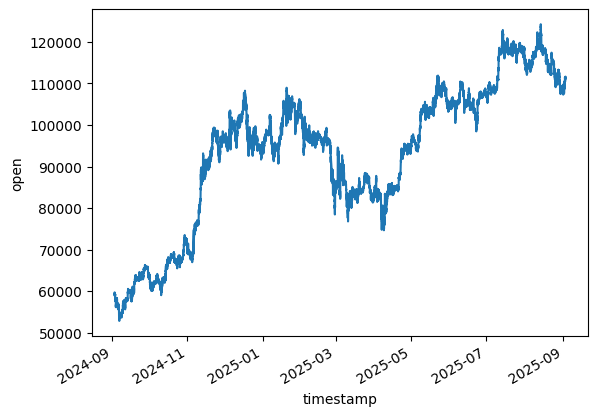

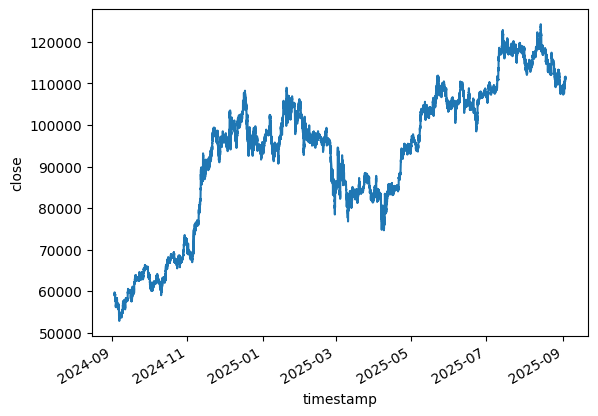

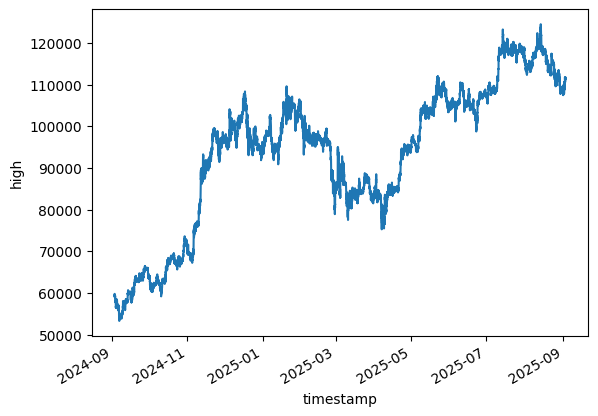

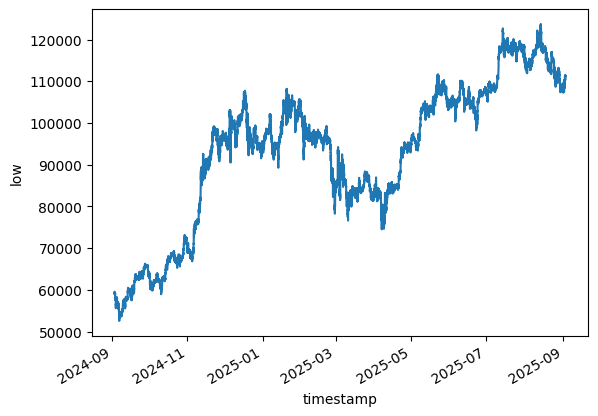

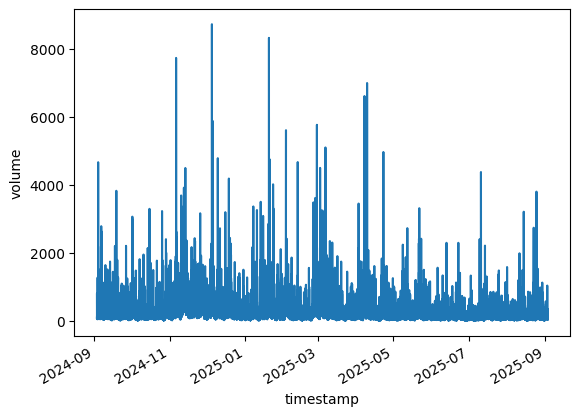

In [169]:
plot_line_chart(df, "timestamp", OCHLV)

# Feature Selection

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

Feature importance

In [ ]:
xgb_open = XGBRegressor(objective='reg:squarederror')

### Spliting the dataset into training and test

In [ ]:
dataset = dataset.sort_values('timestamp')

In [ ]:
cutoff_date = dataset['timestamp'].quantile(0.8)
open_train = dataset[dataset['timestamp'] < cutoff_date]
open_test = dataset[dataset['timestamp'] >= cutoff_date]

In [ ]:
open_train.tail(10)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,close_step_7,close_step_8,close_step_9,close_step_10,close_step_11,close_step_12,close_step_13,close_step_14,close_step_15,close_step_16
28020,2025-06-21 21:45:00,101827.31,101827.31,101401.57,101455.61,218.968430,28.998584,102351.165423,0.014421,-0.093314,...,101196.00,102120.01,101981.49,102493.80,102904.19,102852.00,102796.01,102564.86,102602.64,102387.00
28021,2025-06-21 22:00:00,101455.61,102000.00,101446.74,101886.93,214.532070,28.998584,102334.404209,0.014421,-0.076757,...,102120.01,101981.49,102493.80,102904.19,102852.00,102796.01,102564.86,102602.64,102387.00,102409.90
28022,2025-06-21 22:15:00,101886.92,101983.86,101727.10,101903.81,132.401480,21.584512,102324.578615,0.014421,-0.058361,...,101981.49,102493.80,102904.19,102852.00,102796.01,102564.86,102602.64,102387.00,102409.90,102196.30
28023,2025-06-21 22:30:00,101903.80,101944.54,101610.00,101682.56,169.091300,21.584512,102280.291722,0.014421,-0.054513,...,102493.80,102904.19,102852.00,102796.01,102564.86,102602.64,102387.00,102409.90,102196.30,102376.68
28024,2025-06-21 22:45:00,101682.56,101900.65,101610.00,101772.96,136.363850,21.584512,102253.985533,0.014421,-0.040403,...,102904.19,102852.00,102796.01,102564.86,102602.64,102387.00,102409.90,102196.30,102376.68,102347.64
28025,2025-06-21 23:00:00,101772.97,101875.97,101564.44,101576.98,185.229060,28.998584,102173.163255,0.014421,-0.038404,...,102852.00,102796.01,102564.86,102602.64,102387.00,102409.90,102196.30,102376.68,102347.64,102380.00
28026,2025-06-21 23:15:00,101576.98,101664.00,101370.05,101416.65,207.000760,28.998584,102051.443419,0.014421,-0.041804,...,102796.01,102564.86,102602.64,102387.00,102409.90,102196.30,102376.68,102347.64,102380.00,102158.05
28027,2025-06-21 23:30:00,101416.66,101416.66,100939.65,101196.00,486.871950,28.998584,101918.925666,0.014421,-0.052115,...,102564.86,102602.64,102387.00,102409.90,102196.30,102376.68,102347.64,102380.00,102158.05,102234.35
28028,2025-06-21 23:45:00,101196.00,102322.41,100837.90,102120.01,262.193494,28.998584,101922.130724,0.014421,0.005635,...,102602.64,102387.00,102409.90,102196.30,102376.68,102347.64,102380.00,102158.05,102234.35,102375.40
28029,2025-06-22 00:00:00,102120.02,102588.71,101839.96,101981.49,192.319329,28.998584,101922.701039,-0.349904,0.036470,...,102387.00,102409.90,102196.30,102376.68,102347.64,102380.00,102158.05,102234.35,102375.40,102645.84


In [ ]:
X_open_train = open_train.drop(columns=['open', 'timestamp'])
y_open_train = open_train['open']
X_open_test = open_test.drop(columns=['open', 'timestamp'])
y_open_test = open_test['open']

#### Ploting train and test dataset

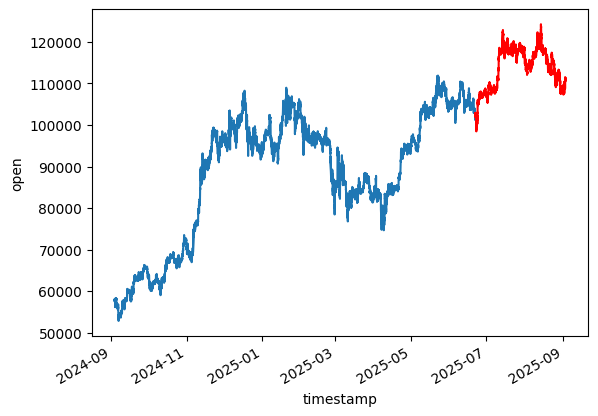

In [ ]:
#### Ploting train dataset
sns.lineplot(x="timestamp", y="open", data=open_train)
sns.lineplot(x="timestamp", y="open", data=open_test, color="red")
plt.gcf().autofmt_xdate()
plt.show()

In [ ]:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.8}
{'subsample': 0.6, 'reg_lambda': 0, 'reg_alpha': 5, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 1.0}

In [ ]:
['DONCHIAN_HIGH',
 'close',
 'DONCHIAN_LOW',
 'high',
 'low',
 'DONCHIAN_MIDDLE',
 'WMA',
 'KAMA',
 'dayofyear',
 'BBANDS_MIDDLE',
 'BBANDS_HIGH',
 'KELTNER_HIGH',
 'EMA',
 'KELTNER_MIDDLE',
 'KELTNER_LOW']

In [ ]:
['DONCHIAN_HIGH',
 'close',
 'DONCHIAN_LOW',
 'low',
 'high',
 'DONCHIAN_MIDDLE',
 'KELTNER_LOW',
 'VWAP',
 'BBANDS_HIGH',
 'WMA',
 'dayofyear',
 'KAMA',
 'BBANDS_MIDDLE',
 'KELTNER_MIDDLE']

In [1]:
import subprocess

# Check if NVIDIA GPU is available
try:
    subprocess.run(['nvidia-smi'], check=True, capture_output=True)
    print("✓ NVIDIA GPU detected")
except:
    print("✗ No NVIDIA GPU found")

✓ NVIDIA GPU detected


In [2]:
import subprocess

# Check CUDA version
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(result.stdout)
    # Look for "CUDA Version: X.X" in the output
except:
    print("Could not get CUDA info")

Tue Sep 30 22:20:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1660 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| 26%   55C    P2             45W /  125W |    1175MiB /   6144MiB |     40%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----